# COSC2753 Assignment 2 — Fashion Intelligence System
# Task 1 — `articleType` Classification

**Prerequisite: run `COSC2753_A2_Preprocessing.ipynb` first.** This notebook loads the
artifacts that notebook writes to `../data/processed/` rather than repeating the cleaning,
splitting and encoding itself.

Loading rather than re-running matters for correctness, not just speed. Every notebook that
re-derives the split gets its own `StratifiedGroupKFold` draw, so a row could sit in train
here and validation there — and any score compared across notebooks would be measured
against a different validation set. Reading one saved split guarantees all four notebooks
mean the same thing by "validation".


## Part I — Load the preprocessed data

**MODIFY — this replaces the full preprocessing pipeline that used to be inlined here.**
The eighty-odd cells of Part I/II have been reduced to the three cells below, which read
what `COSC2753_A2_Preprocessing.ipynb` already computed and saved.

### What is loaded, and what is rebuilt

Loaded straight from disk:

| Artifact | File |
|---|---|
| Full cleaned train/validation split | `train_full.csv`, `val_full.csv` |
| Per-task usable subsets (target non-null, encoded) | `holdout_metadata/{target}_{train,val}.csv` |
| Fitted `LabelEncoder` per target | `label_encoders.pkl` |
| Image size, normalisation constants, thresholds, seed | `pipeline_config.json` |

Rebuilt in code, because they are not serialisable objects:

- **`train_transform` / `eval_transform`** — torchvision transforms hold a lambda-free but
  still unpicklable graph. They are reconstructed from the `normalization_mean` and
  `normalization_std` recorded in `pipeline_config.json`, so they are numerically identical
  to the ones used to compute those statistics, not merely similar.
- **`FashionImageDataset`, `get_weighted_sampler`** — ordinary class and function definitions.

### The one thing to watch

`id` is read back with `dtype=str`. Left to infer, pandas returns `int64`, and while
`f"{52003}.jpg"` happens to build a valid filename, an integer `id` breaks every
`set(...) & set(...)` leakage check against a string-keyed id set — silently, by finding no
overlap where overlap exists. The explicit dtype is what keeps those checks meaningful.


In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image
from torch.utils.data import Dataset, WeightedRandomSampler
from torchvision import transforms as T
from sklearn.preprocessing import LabelEncoder

DATA_DIR = Path("../data/raw/FashionDataset")
OUT_DIR = Path("../data/processed")

TRAIN_CSV = DATA_DIR / "train" / "styles_train.csv"
IMAGES_TRAIN_DIR = DATA_DIR / "train" / "images_train"
TEST_PRED_CSV = DATA_DIR / "test" / "styles_prediction.csv"
IMAGES_TEST_DIR = DATA_DIR / "test" / "images_test"

REQUIRED = {
    "config":       OUT_DIR / "pipeline_config.json",
    "encoders":     OUT_DIR / "label_encoders.pkl",
    "train_full":   OUT_DIR / "train_full.csv",
    "val_full":     OUT_DIR / "val_full.csv",
    "holdout_dir":  OUT_DIR / "holdout_metadata",
}
missing = {k: v for k, v in REQUIRED.items() if not v.exists()}
for name, path in REQUIRED.items():
    print(f"[{'OK' if path.exists() else 'MISSING':>7}] {name:12s} {path}")
if missing:
    raise FileNotFoundError(
        "Run COSC2753_A2_Preprocessing.ipynb first -- it writes the files above. "
        f"Missing: {list(missing)}")

for p in [TRAIN_CSV, IMAGES_TRAIN_DIR, TEST_PRED_CSV, IMAGES_TEST_DIR]:
    print(f"[{'OK' if p.exists() else 'MISSING':>7}] {p}")

with open(REQUIRED["config"]) as f:
    config = json.load(f)

RANDOM_STATE = config["random_state"]
IMG_WIDTH = config["image"]["width"]
IMG_HEIGHT = config["image"]["height"]
mean = torch.tensor(config["image"]["normalization_mean"])
std = torch.tensor(config["image"]["normalization_std"])
ARTICLE_TYPE_MIN_COUNT = config["rare_class_thresholds"]["articleType"]
USAGE_MIN_COUNT = config["rare_class_thresholds"]["usage"]

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f"\nSeed {RANDOM_STATE} | images {IMG_HEIGHT}x{IMG_WIDTH} (HxW)")
print(f"Normalisation mean {[round(v, 4) for v in mean.tolist()]}, "
      f"std {[round(v, 4) for v in std.tolist()]}")
print(f"Rare-class thresholds: articleType>={ARTICLE_TYPE_MIN_COUNT}, usage>={USAGE_MIN_COUNT}")

[     OK] config       ../data/processed/pipeline_config.json
[     OK] encoders     ../data/processed/label_encoders.pkl
[     OK] train_full   ../data/processed/train_full.csv
[     OK] val_full     ../data/processed/val_full.csv
[     OK] holdout_dir  ../data/processed/holdout_metadata
[     OK] ../data/raw/FashionDataset/train/styles_train.csv
[     OK] ../data/raw/FashionDataset/train/images_train
[     OK] ../data/raw/FashionDataset/test/styles_prediction.csv
[     OK] ../data/raw/FashionDataset/test/images_test

Seed 42 | images 80x60 (HxW)
Normalisation mean [0.8508, 0.8336, 0.8284], std [0.2709, 0.2829, 0.2858]
Rare-class thresholds: articleType>=20, usage>=100


In [2]:
# dtype={'id': str} is load-bearing -- see the note above.
ID_DTYPE = {"id": str}

train_data = pd.read_csv(OUT_DIR / "train_full.csv", dtype=ID_DTYPE)
val_data = pd.read_csv(OUT_DIR / "val_full.csv", dtype=ID_DTYPE)

with open(OUT_DIR / "label_encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

holdout_dir = OUT_DIR / "holdout_metadata"
train_usable, val_usable = {}, {}
for t in encoders:
    train_usable[t] = pd.read_csv(holdout_dir / f"{t}_train.csv", dtype=ID_DTYPE)
    val_usable[t] = pd.read_csv(holdout_dir / f"{t}_val.csv", dtype=ID_DTYPE)

# `target_columns` maps a task name to the column actually predicted, which is NOT always
# the task name: rare-class grouping means articleType -> articleType_grouped and
# usage -> usage_grouped. Rebuilt by inspecting the saved files rather than hardcoded, so
# it cannot drift out of step with what preprocessing produced.
target_columns = {}
for t in encoders:
    candidates = [f"{t}_grouped", t]
    col = next((c for c in candidates
                if c in train_usable[t].columns and f"{c}_enc" in train_usable[t].columns), None)
    if col is None:
        raise KeyError(
            f"{t}: no encoded target column found. Looked for "
            f"{[c + '_enc' for c in candidates]} in {holdout_dir / f'{t}_train.csv'}. "
            "Re-run the preprocessing notebook to regenerate the holdout files.")
    target_columns[t] = col

# The main split partitions the cleaned dataset exactly, so `df` is recoverable by
# concatenation. Task 2's season split is a separate draw from the same rows (Section
# II.4.1) and is already reflected in the season_* holdout files, so it needs nothing here.
df = pd.concat([train_data, val_data], ignore_index=True)

print(f"train_full: {train_data.shape}   val_full: {val_data.shape}   combined: {df.shape}")
print("\nPer-task usable subsets:")
for t, col in target_columns.items():
    print(f"  {t:12s} -> column {col:20s} train={len(train_usable[t]):>6}  "
          f"val={len(val_usable[t]):>6}  classes={len(encoders[t].classes_):>3}")

# --- integrity checks: the saved split must still be a valid split -----------
assert set(train_data["id"]).isdisjoint(set(val_data["id"])), "id overlap between train and val"
assert set(train_data["dup_group"]).isdisjoint(set(val_data["dup_group"])), \
    "duplicate-image group spans the split"
assert df["id"].is_unique, "duplicate ids in the reloaded data"
for t, col in target_columns.items():
    enc_col = f"{col}_enc"
    n_cls = len(encoders[t].classes_)
    for name, frame in (("train", train_usable[t]), ("val", val_usable[t])):
        assert frame[col].notna().all(), f"{t}: null target in {name}"
        assert frame[enc_col].notna().all(), f"{t}: missing encoded label in {name}"
        assert frame[enc_col].between(0, n_cls - 1).all(), f"{t}: encoded label out of range in {name}"
        assert set(frame[col]).issubset(set(encoders[t].classes_)), \
            f"{t}: {name} contains a class the encoder never saw"
        # The encoded column must actually agree with the encoder, not merely be in range --
        # a stale CSV paired with a newer pickle would pass every check above.
        assert (encoders[t].transform(frame[col]) == frame[enc_col].to_numpy()).all(), \
            f"{t}: {enc_col} disagrees with label_encoders.pkl -- re-run preprocessing"
print("\nIntegrity checks passed: split is disjoint, ids unique, labels in range.")

train_full: (28958, 13)   val_full: (9653, 13)   combined: (38611, 13)

Per-task usable subsets:
  articleType  -> column articleType_grouped  train= 28958  val=  9648  classes= 92
  season       -> column season               train= 28943  val=  9648  classes=  4
  gender       -> column gender               train= 28958  val=  9653  classes=  5
  usage        -> column usage_grouped        train= 28902  val=  9637  classes=  5

Integrity checks passed: split is disjoint, ids unique, labels in range.


In [3]:
def to_rgb(img):
    """Converts the 249 grayscale ('L' mode) files to 3-channel. A module-level function,
    not a lambda, so the transform stays picklable for DataLoader(num_workers>0)."""
    return img.convert("RGB")


# Evaluation pipeline: no augmentation, so it stays a faithful evaluation signal.
eval_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])

# Training pipeline: conservative augmentation only. These are catalog product photos, so a
# vertical flip or a large rotation would produce an item that never occurs in the data.
# fill=255 because the backgrounds are white -- the default fill=0 would paste black wedges
# into every rotated corner and teach the model an artefact absent at evaluation time.
train_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10, fill=255),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])


class FashionImageDataset(Dataset):
    """(image, label) pairs. `target_col` names an already-encoded integer column."""

    def __init__(self, dataframe, images_dir, target_col, transform):
        self.data = dataframe.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.target_col = target_col
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        with Image.open(self.images_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im)
        return img, int(row[self.target_col])


def get_weighted_sampler(data, target_col):
    """Inverse-frequency WeightedRandomSampler. Train split only -- never apply to
    validation, which must keep the real class distribution to stay a fair estimate."""
    counts = data[target_col].value_counts()
    weights = torch.tensor(
        data[target_col].map(lambda c: 1.0 / counts[c]).to_numpy(dtype="float64"),
        dtype=torch.double
    )
    return WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)


# Class weights, computed for reference. Imbalance is handled by the sampler above, not by
# weighting the loss -- applying both would double-count the correction.
class_weights = {}
for t, col in target_columns.items():
    vc = train_usable[t][col].value_counts()
    n_samples, n_classes = len(train_usable[t]), len(encoders[t].classes_)
    w = n_samples / (n_classes * vc)
    class_weights[t] = torch.tensor([w[c] for c in encoders[t].classes_], dtype=torch.float32)

# Verify the reconstructed pipeline against a real image before anything depends on it.
_probe_id = train_data["id"].iloc[0]
_probe = eval_transform(Image.open(IMAGES_TRAIN_DIR / f"{_probe_id}.jpg"))
assert _probe.shape == (3, IMG_HEIGHT, IMG_WIDTH), f"unexpected tensor shape {tuple(_probe.shape)}"
print(f"Transform check: image {_probe_id} -> tensor {tuple(_probe.shape)}, "
      f"range [{_probe.min():.2f}, {_probe.max():.2f}]")
print("Ready: train_data, val_data, df, train_usable, val_usable, encoders,")
print("       train_transform, eval_transform, FashionImageDataset, get_weighted_sampler")

Transform check: image 1164 -> tensor (3, 80, 60), range [-3.00, 0.60]
Ready: train_data, val_data, df, train_usable, val_usable, encoders,
       train_transform, eval_transform, FashionImageDataset, get_weighted_sampler


## Part II — Task 1

Everything below is unchanged. It now runs against the loaded split instead of a locally recomputed one.

# Task 1: Fashion Item Type Classification

**The task:** predict `articleType` (T-shirt, Shoes, Watches, and 89 other categories) from a product photo. Everything below either builds a candidate model, tests one specific idea about improving the best one so far, or verifies something later steps depend on being true.

**The plan:** start simple, add complexity only where the data justifies it, and check every claim against a real validation score — nothing here is assumed, everything is tested.

**How this is organised:**
1. Reuse the already-cleaned, already-split data (Steps 1–8) and double-check it's trustworthy
2. Build three image-only CNNs of increasing sophistication (Steps 9–11)
3. Check whether metadata alone, or metadata combined with the image, adds anything (Steps 11b–11g) — including a hard look at what's actually deployable
4. Compare everything on equal footing (Step 12)
5. Decide on the final model and its current, honest limitations (Steps 13–14)
6. Evaluate it properly and document what's still needed before real test predictions can be generated (Steps 15–16)

**Reusing, not rebuilding:** everything from preprocessing above is used as-is — no data gets reloaded or re-split.

## Step 1 — Reuse the Prepared Train/Validation Split

**Approach:** the cleaning, corruption/duplicate checks, and leak-free split already happened in preprocessing above. This step pulls Task 1's slice of that work into its own variables.

In [4]:
# Reuse the Task 1-specific prepared splits built during preprocessing above.
# These already contain articleType_grouped and articleType_grouped_enc.
task1_train = train_usable['articleType'].copy()
task1_val = val_usable['articleType'].copy()

TASK1_TARGET = 'articleType_grouped'
TASK1_TARGET_ENC = TASK1_TARGET + '_enc'

assert TASK1_TARGET_ENC in task1_train.columns
assert TASK1_TARGET_ENC in task1_val.columns
print(f'Task 1 train: {len(task1_train):,}; validation: {len(task1_val):,}')
print(f'articleType classes: {len(encoders["articleType"].classes_)}')

# Same leakage guarantee as the shared split above: no duplicate-image group
# or id should appear on both sides.
overlap_ids = set(task1_train['id']) & set(task1_val['id'])
overlap_groups = set(task1_train['dup_group']) & set(task1_val['dup_group'])
print(f'id overlap: {len(overlap_ids)} (should be 0)')
print(f'duplicate-image group overlap: {len(overlap_groups)} (should be 0)')


Task 1 train: 28,958; validation: 9,648
articleType classes: 92
id overlap: 0 (should be 0)
duplicate-image group overlap: 0 (should be 0)


**Result:** 28,958 training photos, 9,648 validation photos, zero id or duplicate-image overlap between them — a trustworthy split.

**Next:** look at what's actually in the training data, starting with how the target classes are distributed.

## Step 2 — Look at the `articleType` Class Distribution

**Approach:** knowing how imbalanced this problem is decides which evaluation metric actually makes sense.

Classes in train: 92, in val: 90
Majority class: 'Tshirts' (5122 rows, 17.7%)
Minority class: 'Bath and Body' (1 rows)
Imbalance ratio (majority/minority): 5122.0


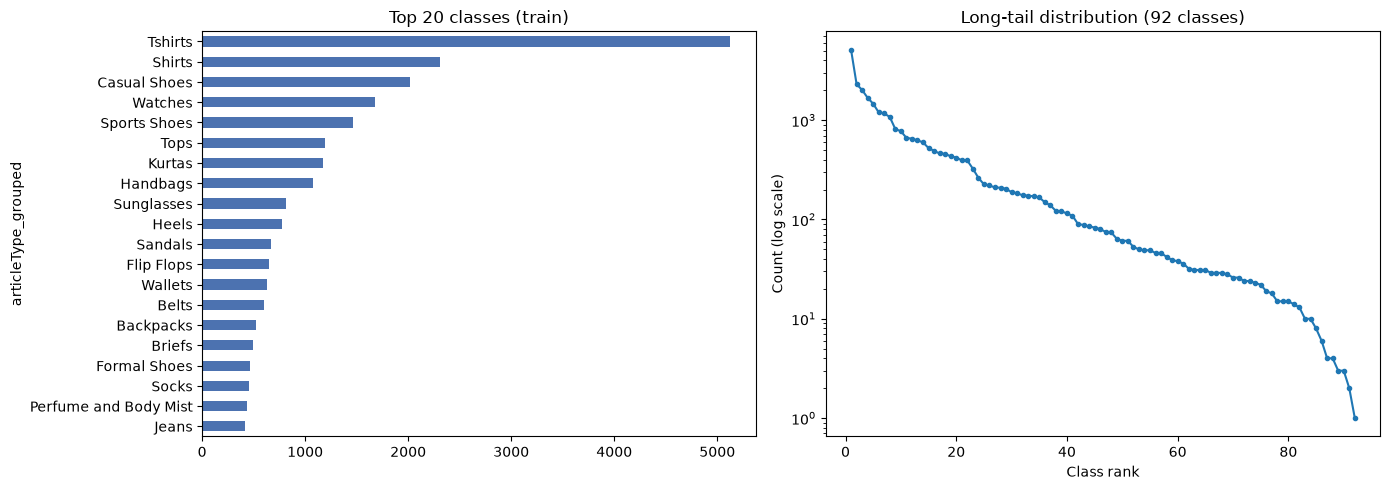

In [5]:
vc_train = task1_train[TASK1_TARGET].value_counts()
vc_val = task1_val[TASK1_TARGET].value_counts()

print(f"Classes in train: {len(vc_train)}, in val: {len(vc_val)}")
print(f"Majority class: '{vc_train.idxmax()}' ({vc_train.max()} rows, {vc_train.max()/len(task1_train)*100:.1f}%)")
print(f"Minority class: '{vc_train.idxmin()}' ({vc_train.min()} rows)")
print(f"Imbalance ratio (majority/minority): {vc_train.max()/vc_train.min():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc_train.head(20).plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].invert_yaxis()
axes[0].set_title('Top 20 classes (train)')

axes[1].plot(range(1, len(vc_train) + 1), vc_train.values, marker='o', markersize=3)
axes[1].set_yscale('log')
axes[1].set_xlabel('Class rank')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title(f'Long-tail distribution ({len(vc_train)} classes)')
plt.tight_layout()
plt.show()


**Result:** 92 categories, wildly imbalanced — the biggest (T-shirts) is ~17.7% of all training photos; several categories have fewer than 20 examples.

**What this means:** a model could look deceptively good on raw accuracy just by nailing T-shirts and ignoring rare categories. This is why **macro-F1** (equal weight per category, regardless of frequency) is the primary metric throughout this notebook.

**Next:** turn the text labels into numbers a model can train on.

## Step 3 — Verify Label Encoding

**Approach:** encode each category as an integer (0–91), and check the mapping actually works before trusting it downstream.

In [6]:
encoder1 = encoders['articleType']
N_CLASSES_1 = len(encoder1.classes_)

# Encoded values must be a contiguous range 0..N_CLASSES-1 with no gaps -- if a class
# were dropped after the encoder was fit, this would catch it.
seen_codes = set(task1_train[TASK1_TARGET_ENC].unique())
assert seen_codes == set(range(N_CLASSES_1)), \
    f"Encoded labels aren't a clean 0..{N_CLASSES_1-1} range -- got {sorted(seen_codes)[:5]}..."

print(f"{N_CLASSES_1} classes, encoded as a contiguous 0..{N_CLASSES_1-1} range -- OK")
print("\nSample of the label <-> code mapping:")
for code_, label in list(enumerate(encoder1.classes_))[:5]:
    print(f"  {code_:>3} -> {label}")
print("  ...")

# Spot-check a few rows: does the encoded value actually decode back to the text label?
sample_rows = task1_train.sample(5, random_state=RANDOM_STATE)
for _, row in sample_rows.iterrows():
    decoded = encoder1.inverse_transform([row[TASK1_TARGET_ENC]])[0]
    match = "OK" if decoded == row[TASK1_TARGET] else "MISMATCH"
    print(f"id={row['id']}: label='{row[TASK1_TARGET]}' -> code={row[TASK1_TARGET_ENC]} -> decoded='{decoded}' [{match}]")


92 classes, encoded as a contiguous 0..91 range -- OK

Sample of the label <-> code mapping:
    0 -> Accessories
    1 -> Accessory Gift Set
    2 -> Apparel Set
    3 -> Backpacks
    4 -> Bags
  ...
id=27368: label='Tshirts' -> code=85 -> decoded='Tshirts' [OK]
id=35244: label='Socks' -> code=68 -> decoded='Socks' [OK]
id=23235: label='Kurtas' -> code=41 -> decoded='Kurtas' [OK]
id=22555: label='Deodorant' -> code=19 -> decoded='Deodorant' [OK]
id=23522: label='Perfume and Body Mist' -> code=58 -> decoded='Perfume and Body Mist' [OK]


**Result:** all spot-checks passed — the encoding decodes back correctly.

**Next:** confirm nothing is missing or broken in the labels themselves.

## Step 4 — Check for Missing or Invalid Labels

**Approach:** cheap insurance against a crash or silently wrong training later.

In [7]:
for name, df in [('train', task1_train), ('val', task1_val)]:
    n_missing_text = df[TASK1_TARGET].isna().sum()
    n_missing_enc = df[TASK1_TARGET_ENC].isna().sum()
    n_out_of_range = ((df[TASK1_TARGET_ENC] < 0) | (df[TASK1_TARGET_ENC] >= N_CLASSES_1)).sum()

    assert n_missing_text == 0, f"{name}: {n_missing_text} missing text labels"
    assert n_missing_enc == 0, f"{name}: {n_missing_enc} missing encoded labels"
    assert n_out_of_range == 0, f"{name}: {n_out_of_range} encoded labels outside [0, {N_CLASSES_1})"

    print(f"{name}: no missing labels, no out-of-range codes ({len(df)} rows checked)")


train: no missing labels, no out-of-range codes (28958 rows checked)
val: no missing labels, no out-of-range codes (9648 rows checked)


**Result:** clean — nothing missing, nothing out of range.

**Next:** confirm the image files those labels point to actually exist.

## Step 5 — Verify Image Paths

**Approach:** better to find a missing file now than deep inside a training loop.

In [8]:
train_image_ids = {p.stem for p in IMAGES_TRAIN_DIR.glob('*.jpg')}

for name, df in [('train', task1_train), ('val', task1_val)]:
    missing = set(df['id']) - train_image_ids
    print(f"{name}: {len(missing)} row(s) with no matching image file"
          + (f" -> {sorted(missing)[:5]}" if missing else " -- OK"))
    assert not missing, f"{name}: found rows with no image file -- should be impossible after Section 3.2"


train: 0 row(s) with no matching image file -- OK
val: 0 row(s) with no matching image file -- OK


**Result:** all present — no missing files.

**Next:** wrap the verified data into a PyTorch `Dataset`.

## Step 6 — Create the PyTorch Dataset

**Approach:** build the bridge between "a folder of JPEGs and a CSV" and something PyTorch can actually train on.

**Speed optimisation:** a default `Dataset` re-reads and re-decodes an image from disk every time it's needed — meaning the same ~29,000 files get read again every epoch, for every model in this notebook. Since the whole set fits comfortably in memory, `CachedFashionImageDataset` loads every image once, up front, and serves it from RAM after that. What the model sees doesn't change — only where the bytes come from.

In [9]:
class CachedFashionImageDataset(Dataset):
    """Same interface as FashionImageDataset, but opens and RGB-converts
    every image into memory ONCE at construction time, instead of hitting
    disk + decoding JPEG on every __getitem__ call, every epoch, every
    model trained on this data."""

    def __init__(self, dataframe, images_dir, target_col_enc, transform):
        self.df = dataframe.reset_index(drop=True)
        self.target_col_enc = target_col_enc
        self.transform = transform
        print(f"Pre-loading {len(self.df)} images into memory...")
        self.cache = []
        for img_id in self.df['id']:
            with Image.open(images_dir / f"{img_id}.jpg") as im:
                self.cache.append(to_rgb(im).copy())
        print("Done.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = self.transform(self.cache[idx])
        label = int(self.df.iloc[idx][self.target_col_enc])
        return img, torch.tensor(label, dtype=torch.long)


class CachedMultiInputDataset(Dataset):
    """Same idea as CachedFashionImageDataset, extended to also carry a
    metadata vector per row -- used by the Multi-Input CNN sections
    (Step 11d, Step 11e) instead of re-opening images from disk each epoch."""

    def __init__(self, dataframe, metadata_array, images_dir, target_col_enc, transform):
        self.df = dataframe.reset_index(drop=True)
        self.metadata = np.asarray(metadata_array, dtype=np.float32)
        assert len(self.metadata) == len(self.df), "metadata_array must align with dataframe rows"
        self.target_col_enc = target_col_enc
        self.transform = transform
        print(f"Pre-loading {len(self.df)} images into memory...")
        self.cache = []
        for img_id in self.df['id']:
            with Image.open(images_dir / f"{img_id}.jpg") as im:
                self.cache.append(to_rgb(im).copy())
        print("Done.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = self.transform(self.cache[idx])
        meta = torch.tensor(self.metadata[idx], dtype=torch.float32)
        label = int(self.df.iloc[idx][self.target_col_enc])
        return img, meta, torch.tensor(label, dtype=torch.long)


In [10]:
train_ds1 = CachedFashionImageDataset(task1_train, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, train_transform)
val_ds1 = CachedFashionImageDataset(task1_val, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, eval_transform)

print(f"train_ds1: {len(train_ds1)} images")
print(f"val_ds1:   {len(val_ds1)} images")

# Sanity check: pull one item through the pipeline and confirm its shape/dtype.
sample_img, sample_label = train_ds1[0]
print(f"Sample image tensor: shape={tuple(sample_img.shape)}, dtype={sample_img.dtype}")
print(f"Sample label: {sample_label.item()} ('{encoder1.classes_[sample_label.item()]}')")


Pre-loading 28958 images into memory...
Done.
Pre-loading 9648 images into memory...
Done.
train_ds1: 28958 images
val_ds1:   9648 images
Sample image tensor: shape=(3, 80, 60), dtype=torch.float32
Sample label: 85 ('Tshirts')


**Result:** a sample image comes out as a `(3, 80, 60)` tensor with the correct label attached — the pipeline works end to end.

**Next:** wrap the `Dataset` in a `DataLoader` so training can pull batches, not single images.

## Step 7 — Create DataLoaders

**Approach:** batch the data for the GPU, and address class imbalance here specifically — via a sampler that shows the model rare categories more often than their raw frequency would suggest.

In [11]:
import copy
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
# MODIFY: the corrected preprocessing no longer imports these (they were unused
# there), but Steps 8-16 below need them -- import them here instead.
from sklearn.metrics import accuracy_score, f1_score


def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():          # Apple Silicon
        return torch.device('mps')
    return torch.device('cpu')

DEVICE = get_device()
BATCH_SIZE, EPOCHS, NUM_WORKERS = 64, 50, 6  # 0: safe in Jupyter/VS Code notebooks -- see markdown above
print("Using device:", DEVICE)

sampler1 = get_weighted_sampler(task1_train, TASK1_TARGET_ENC)

train_loader1 = DataLoader(train_ds1, batch_size=BATCH_SIZE, sampler=sampler1,
                            num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader1 = DataLoader(val_ds1, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

print(f"train_loader1: {len(train_loader1)} batches of up to {BATCH_SIZE}")
print(f"val_loader1:   {len(val_loader1)} batches of up to {BATCH_SIZE}")


Using device: cuda
train_loader1: 453 batches of up to 64
val_loader1:   151 batches of up to 64


**Result:** training uses a `WeightedRandomSampler` (oversamples rare categories); validation deliberately does not, so it stays a faithful, real-world-imbalanced test. `NUM_WORKERS=0` throughout — parallel loading is unreliable inside a Jupyter/VS Code notebook on macOS specifically.

**Next:** decide exactly how "good" gets measured, before training the first model.

## Step 8 — Establish the Evaluation Metric

**Approach:** set a floor first, so it's obvious how misleading raw accuracy alone could be.

In [12]:
majority_class = task1_train[TASK1_TARGET_ENC].mode()[0]
baseline_preds = np.full(len(task1_val), majority_class)
baseline_acc = accuracy_score(task1_val[TASK1_TARGET_ENC], baseline_preds)
baseline_f1 = f1_score(task1_val[TASK1_TARGET_ENC], baseline_preds, average='macro', zero_division=0)

print(f"Majority class: '{encoder1.classes_[majority_class]}'")
print(f"Baseline accuracy: {baseline_acc:.3f} | Baseline macro-F1: {baseline_f1:.3f}")


Majority class: 'Tshirts'
Baseline accuracy: 0.172 | Baseline macro-F1: 0.003


**Result:** the majority-class guess reaches 0.172 accuracy but only 0.003 macro-F1.

**What this means:** that gap is the actual argument for using macro-F1 as the primary metric for the rest of this notebook.

**Next:** build the shared training machinery every model below reuses.

### Shared Training Utilities (used by every model below)

**Approach:** one training loop, written once, reused by every model — image-only, metadata-only, or fused.

In [13]:
def get_param_groups(model, weight_decay):
    """Splits a model's parameters into two optimizer param groups, matching
    Keras' `kernel_regularizer=l2(...)` -- L2 applies only to conv/linear
    KERNEL (weight) tensors, never to biases or BatchNorm parameters."""
    decay, no_decay = [], []
    for param in model.parameters():
        if not param.requires_grad:
            continue
        (decay if param.ndim >= 2 else no_decay).append(param)
    return [
        {"params": decay, "weight_decay": weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ]


class EarlyStopping:
    """Stops training when a monitored score stops improving.
    mode='max' for metrics like macro-F1 (higher is better).
    mode='min' for metrics like validation loss (lower is better)."""
    def __init__(self, patience=5, delta=0, mode='max'):
        assert mode in ('max', 'min')
        self.patience, self.delta, self.mode = patience, delta, mode
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_state = None

    def __call__(self, value, model):
        score = value if self.mode == 'max' else -value
        if self.best_score is None or score > self.best_score + self.delta:
            self.best_score = score
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def load_best_model(self, model):
        model.load_state_dict(self.best_state)
        return model


def to_device(batch):
    """(image, label) -> inputs=[image]. (image, metadata, label) -> inputs=[image, metadata]."""
    *inputs, labels = batch
    return [x.to(DEVICE) for x in inputs], labels.to(DEVICE)


def run_epoch(model, loader, criterion, optimiser=None, desc=''):
    train_mode = optimiser is not None
    model.train() if train_mode else model.eval()

    running_loss, n, preds, actual = 0.0, 0, [], []
    with torch.set_grad_enabled(train_mode):
        for batch in tqdm(loader, desc=desc, leave=train_mode):
            inputs, labels = to_device(batch)
            logits = model(*inputs)
            loss = criterion(logits, labels)
            if train_mode:
                optimiser.zero_grad()
                loss.backward()
                optimiser.step()
            bs = labels.size(0)
            running_loss += loss.item() * bs
            n += bs
            preds.extend(logits.argmax(1).detach().cpu().numpy())
            actual.extend(labels.cpu().numpy())

    return running_loss / n, f1_score(actual, preds, average='macro', zero_division=0)


def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes[0].plot(history['train_loss'], label='Train loss')
    axes[0].plot(history['val_loss'], label='Val loss')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(history['train_f1'], label='Train macro-F1')
    axes[1].plot(history['val_f1'], label='Val macro-F1')
    axes[1].set_title('Macro-F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def fit(model, loader_tr, loader_va, model_name='model', epochs=EPOCHS, patience=5, lr=3e-4,
        weight_decay=1e-4, param_groups=None, class_weights=None, criterion=None):
    """class_weights=None and criterion=None (the defaults) reproduce the exact
    original behaviour -- both are backward-compatible additions. If `criterion`
    is given explicitly (e.g. a FocalLoss instance), it's used as-is and
    `class_weights` is ignored; otherwise the standard weighted/unweighted
    CrossEntropyLoss from before is built automatically."""
    if criterion is None:
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    optim_params = param_groups if param_groups is not None else model.parameters()
    optimiser = torch.optim.AdamW(optim_params, lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
    early_stopping = EarlyStopping(patience=patience, delta=0.0, mode='min')
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_f1 = best_val_loss = best_epoch = None

    for epoch in range(epochs):
        tag = f'{model_name} {epoch + 1}/{epochs}'
        train_loss, train_f1 = run_epoch(model, loader_tr, criterion, optimiser, desc=f'{tag} train')
        val_loss, val_f1 = run_epoch(model, loader_va, criterion, None, desc=f'{tag} val')

        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1); history['val_f1'].append(val_f1)
        print(f'Epoch {epoch + 1}/{epochs} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - '
              f'train_f1: {train_f1:.4f} - val_f1: {val_f1:.4f} - lr: {optimiser.param_groups[0]["lr"]:.2e}')

        scheduler.step(val_loss)
        early_stopping(val_loss, model)
        if early_stopping.counter == 0:
            best_val_f1, best_val_loss, best_epoch = val_f1, val_loss, epoch + 1
        if early_stopping.early_stop:
            print(f'Early stopping triggered at epoch {epoch + 1} (best epoch was {best_epoch})')
            break

    model = early_stopping.load_best_model(model)
    plot_training_curves(history, model_name)
    print(f'>>> Best checkpoint for {model_name}: epoch {best_epoch} '
          f'(val_loss={best_val_loss:.4f}, val_f1={best_val_f1:.4f})')
    return model, best_val_f1, best_epoch


def get_predictions(model, loader):
    model.eval()
    preds, actual = [], []
    with torch.no_grad():
        for batch in loader:
            inputs, labels = to_device(batch)
            preds.extend(model(*inputs).argmax(1).cpu().numpy())
            actual.extend(labels.cpu().numpy())
    return np.array(actual), np.array(preds)


def bootstrap_metric_ci(y_true, y_pred, metric_fn, n_boot=1000, ci=0.95, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    n = len(y_true)
    scores = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        scores[i] = metric_fn(y_true[idx], y_pred[idx])
    alpha = (1 - ci) / 2
    return scores.mean(), np.quantile(scores, alpha), np.quantile(scores, 1 - alpha)


def report_bootstrap_ci(name, y_true, y_pred, n_boot=1000, ci=0.95):
    f1_mean, f1_lo, f1_hi = bootstrap_metric_ci(
        y_true, y_pred, lambda yt, yp: f1_score(yt, yp, average='macro', zero_division=0),
        n_boot=n_boot, ci=ci)
    print(f"{name}: macro-F1={f1_mean:.3f} (CI {f1_lo:.3f}-{f1_hi:.3f})")
    return {"name": name, "f1_mean": f1_mean, "f1_ci_low": f1_lo, "f1_ci_high": f1_hi}


**What each piece does:**
- **`get_param_groups`** applies weight regularisation (L2) only to a model's real decision-making weights, not BatchNorm's internal numbers.
- **`EarlyStopping`** stops training once validation stops improving, preventing wasted time and excess overfitting.
- **`fit()`** is the actual training loop — show a batch, measure how wrong the guess was, nudge the weights slightly toward less wrong, repeat.
- **Where's softmax?** Every model outputs 92 raw numbers per photo that don't mean anything alone. Softmax turns them into probabilities that sum to 100% — handled internally by `CrossEntropyLoss`, never written as a separate step.

**Next:** build the first model — deliberately as simple as possible.

## Step 9 — CNN Baseline

**Approach:** the simplest network that could plausibly work. Not meant to be good — meant to be a floor every more complex model has to clearly beat.

**MODIFY — two models were removed from this notebook.** The architecture progression used to
run BasicCNN → VGG-Style → ResNet-Style → SE-Residual, and the metadata-only baseline was run
twice, with Logistic Regression and again with a Random Forest.

- **VGG-Style CNN (old Step 10) removed.** It sat between the baseline and the residual
  models and changed no conclusion: the baseline establishes the floor, and the residual
  architectures establish what depth plus skip connections buy. A fourth rung on the ladder
  cost a full training run to confirm something the other three already showed.
- **Random Forest metadata baseline removed.** Logistic Regression already establishes that
  metadata alone is far below any image model. The Random Forest landed within ~0.015 macro-F1
  of it and supported exactly the same conclusion, so it was a second answer to a settled
  question.

Both were working models producing valid numbers — they were redundant, not wrong. Every
remaining model earns its place: a baseline floor, two from-scratch architectures worth
comparing, a metadata-only reference point, and the multi-input variants.

In [14]:
# Separate epoch budgets per model -- lets each be trained/tuned independently
# rather than sharing one global cap. Early stopping (patience=5) can still stop
# any of them sooner; these are ceilings, not fixed run lengths.
EPOCHS_BASELINE = 20
# MODIFY: EPOCHS_VGG removed along with the VGG model (see Step 9's note).
EPOCHS_RESNET = 30
# MODIFY: budget for the new from-scratch SE-Residual CNN added in Step 11a.
EPOCHS_SERES = 35


CNN Baseline 1/20 train:   0%|          | 0/453 [00:00<?, ?it/s]

CNN Baseline 1/20 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/20 - train_loss: 4.1378 - val_loss: 3.6330 - train_f1: 0.0376 - val_f1: 0.0369 - lr: 3.00e-04


CNN Baseline 2/20 train:   0%|          | 0/453 [00:00<?, ?it/s]

CNN Baseline 2/20 val:   0%|          | 0/151 [00:00<?, ?it/s]

...

CNN Baseline 17/20 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 17/20 - train_loss: 1.3782 - val_loss: 1.8526 - train_f1: 0.6025 - val_f1: 0.3639 - lr: 1.50e-04


CNN Baseline 18/20 train:   0%|          | 0/453 [00:00<?, ?it/s]

CNN Baseline 18/20 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 18/20 - train_loss: 1.3676 - val_loss: 1.9628 - train_f1: 0.6001 - val_f1: 0.3485 - lr: 1.50e-04
Early stopping triggered at epoch 18 (best epoch was 13)


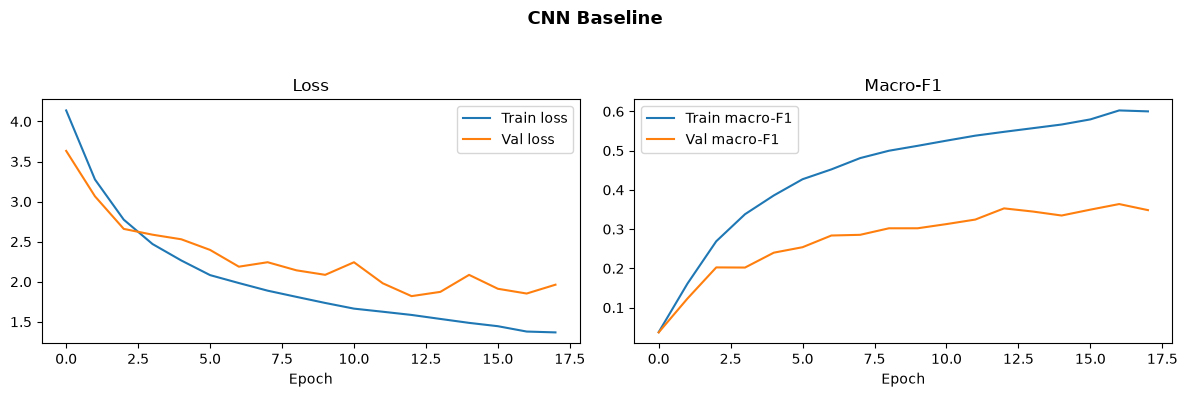

>>> Best checkpoint for CNN Baseline: epoch 13 (val_loss=1.8202, val_f1=0.3529)


In [15]:
class BasicCNN(nn.Module):
    """Three plain conv+ReLU+pool layers (16->32->64 filters). No block
    structure, no regularization at all -- the simplest possible baseline."""

    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out_dim = out_dim
        self.proj = nn.Linear(64, out_dim)

    def forward(self, x):
        return self.proj(self.pool(self.features(x)).flatten(1))


class Classifier(nn.Module):
    """Thin classification head on top of any encoder -- turns its embedding
    into class logits. Shared by every image-only model in Steps 9-11."""

    def __init__(self, encoder, n_classes):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(encoder.out_dim, n_classes)

    def forward(self, x):
        return self.head(self.encoder(x))


torch.manual_seed(RANDOM_STATE)
model_baseline = Classifier(BasicCNN(), N_CLASSES_1).to(DEVICE)
model_baseline, f1_baseline, epoch_baseline = fit(
    model_baseline, train_loader1, val_loader1, model_name="CNN Baseline", epochs=EPOCHS_BASELINE)


**The building blocks, in plain terms:**
- **Convolutions** scan for patterns — edges and colours first, then more complex shapes.
- **ReLU** turns negative numbers to zero and leaves positive ones unchanged after each convolution — this simple rule is what lets a network learn bendy, non-linear patterns instead of collapsing into one big linear function.
- **Max pooling** shrinks the image after each block, keeping the strongest signal and letting later layers see more of the photo at once.

**Result:** a real, meaningful jump over the majority-class floor — the pipeline genuinely learns from pixels — but with a low ceiling, exactly as expected from a deliberately minimal design.

**Next:** add the two things this version is missing — more depth, and regularisation to keep that depth from just memorising the training set.

## Step 11 — ResNet-Style CNN

**Approach:** adds skip connections (ResNet's defining idea), trained completely from scratch — no pretrained weights anywhere.

ResNet-style CNN 1/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

ResNet-style CNN 1/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 1.4996 - val_loss: 1.3330 - train_f1: 0.5973 - val_f1: 0.4934 - lr: 3.00e-04


ResNet-style CNN 2/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

ResNet-style CNN 2/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

...

ResNet-style CNN 17/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 17/30 - train_loss: 0.0717 - val_loss: 0.6720 - train_f1: 0.9754 - val_f1: 0.6878 - lr: 7.50e-05


ResNet-style CNN 18/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

ResNet-style CNN 18/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 18/30 - train_loss: 0.0619 - val_loss: 0.6742 - train_f1: 0.9793 - val_f1: 0.6825 - lr: 7.50e-05
Early stopping triggered at epoch 18 (best epoch was 13)


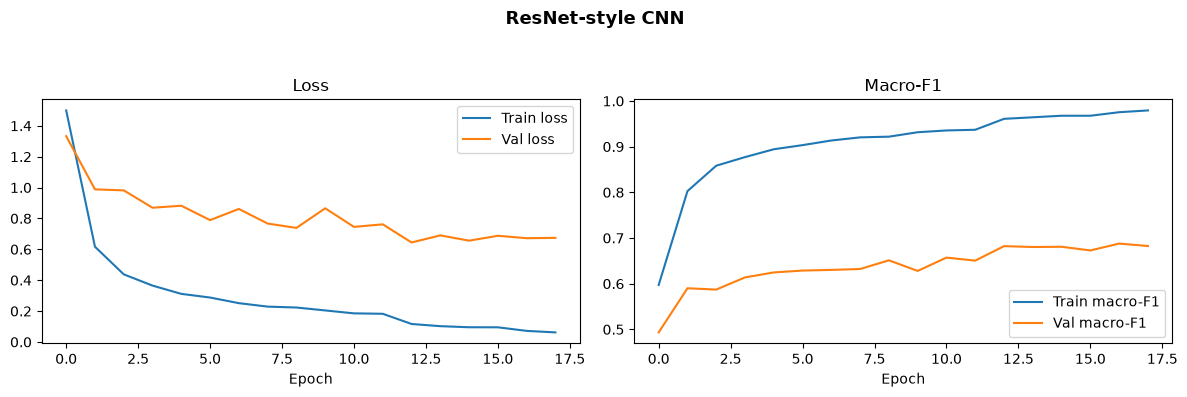

>>> Best checkpoint for ResNet-style CNN: epoch 13 (val_loss=0.6444, val_f1=0.6822)


In [16]:
from torchvision.models import resnet18


class ResNetStyleCNN(nn.Module):
    """ResNet18 architecture, randomly initialized -- trains entirely on
    this dataset, no pretrained weights."""

    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=None)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.out_dim = out_dim
        self.proj = nn.Linear(512, out_dim)

    def forward(self, x):
        return self.proj(self.backbone(x))


torch.manual_seed(RANDOM_STATE)
model_resnet = Classifier(ResNetStyleCNN(), N_CLASSES_1).to(DEVICE)
model_resnet, f1_resnet, epoch_resnet = fit(
    model_resnet, train_loader1, val_loader1, model_name="ResNet-style CNN", epochs=EPOCHS_RESNET)


**What a skip connection does:** lets information jump past a layer instead of being forced through every step in strict order. In very deep networks, the training signal can weaken the further back it travels; a skip connection gives it a shortcut, so even a deep network trains reliably.

**Result:** a further real improvement over the CNN baseline — smaller than the previous jump, but consistent with a more modern architecture.

**Next:** this is now the best self-trained, image-only model, and the encoder used wherever a strong backbone is needed later. Before tuning it further, check something more fundamental — how much can be predicted from metadata alone, with no photo at all?

## Step 11a — SE-Residual CNN (from scratch, no pretrained weights)

**Approach:** the strongest image-only architecture in this notebook, designed for 80×60 catalog photos specifically rather than borrowed from a 224×224 ImageNet model.

**Why this should beat the models above, and why it is still from scratch.**
Every layer is randomly initialised — `weights=None` nowhere required, because none of
this comes from torchvision. Three concrete changes over the previous best:

1. **No stem downsampling.** `resnet18` opens with a 7×7 stride-2 convolution followed by
   a stride-2 max-pool, which takes an 80×60 image down to 20×15 before the first residual
   block ever runs. That design is for 224×224 inputs. Here it throws away most of the
   spatial detail up front — and at this resolution the difference between a shirt and a
   kurta is exactly that detail. This encoder starts with a stride-1 3×3 stem and
   downsamples gradually.
2. **Squeeze-excite gating.** Each block learns which of its own channels matter for the
   current image and rescales them. Cheap in parameters, and it helps most when classes
   differ by which cues are relevant rather than by their overall shape.
3. **Pre-activation ordering** (BN → SiLU → conv, with an identity skip path), which trains
   more stably at depth than the post-activation blocks used earlier.


SE-Residual CNN (from scratch) 1/35 train:   0%|          | 0/453 [00:00<?, ?it/s]

SE-Residual CNN (from scratch) 1/35 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/35 - train_loss: 3.1865 - val_loss: 2.3977 - train_f1: 0.1715 - val_f1: 0.1998 - lr: 3.00e-04


SE-Residual CNN (from scratch) 2/35 train:   0%|          | 0/453 [00:00<?, ?it/s]

SE-Residual CNN (from scratch) 2/35 val:   0%|          | 0/151 [00:00<?, ?it/s]

...

SE-Residual CNN (from scratch) 34/35 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 34/35 - train_loss: 0.1136 - val_loss: 0.5802 - train_f1: 0.9615 - val_f1: 0.7325 - lr: 1.87e-05


SE-Residual CNN (from scratch) 35/35 train:   0%|          | 0/453 [00:00<?, ?it/s]

SE-Residual CNN (from scratch) 35/35 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 35/35 - train_loss: 0.1100 - val_loss: 0.5787 - train_f1: 0.9623 - val_f1: 0.7125 - lr: 1.87e-05


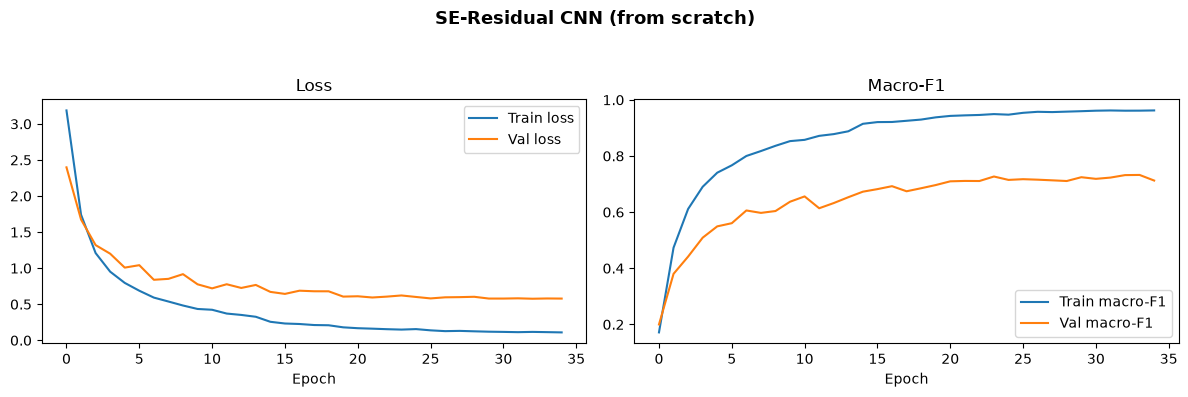

>>> Best checkpoint for SE-Residual CNN (from scratch): epoch 33 (val_loss=0.5766, val_f1=0.7319)
>>> SE-Residual CNN: val macro-F1 = 0.732, 2.88M parameters
>>> ResNet-style CNN for comparison: 0.682


In [17]:
# MODIFY: new architecture. Everything here is randomly initialised -- there is no
# torchvision backbone and no `weights=` argument anywhere, so this remains a
# fully self-trained model and is eligible for final selection.
import torch.nn.functional as F


class SqueezeExcite(nn.Module):
    """Channel attention: pool each feature map to one number, learn a per-channel
    gate from those numbers, then rescale. Lets the network decide which feature
    maps matter for a given image rather than weighting all of them equally."""

    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.fc1 = nn.Linear(channels, hidden)
        self.fc2 = nn.Linear(hidden, channels)

    def forward(self, x):
        s = x.mean(dim=(2, 3))                       # global average pool -> (B, C)
        s = torch.sigmoid(self.fc2(F.silu(self.fc1(s))))
        return x * s[:, :, None, None]


class SEResidualBlock(nn.Module):
    """Pre-activation residual block: BN -> SiLU -> conv, twice, plus a
    squeeze-excite gate and a skip connection. Pre-activation keeps the skip path
    a clean identity, which trains more stably at depth than the post-activation
    ordering used by the earlier blocks in this notebook."""

    def __init__(self, in_ch, out_ch, stride=1, drop=0.0):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.se = SqueezeExcite(out_ch)
        self.drop = nn.Dropout2d(drop) if drop > 0 else nn.Identity()
        self.shortcut = (nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)
                         if (stride != 1 or in_ch != out_ch) else nn.Identity())

    def forward(self, x):
        out = F.silu(self.bn1(x))
        shortcut = self.shortcut(out if not isinstance(self.shortcut, nn.Identity) else x)
        out = self.conv1(out)
        out = self.conv2(F.silu(self.bn2(out)))
        out = self.se(self.drop(out))
        return out + shortcut


class SEResidualCNN(nn.Module):
    """From-scratch SE-residual encoder sized for 80x60 inputs.
    Stages 32 -> 64 -> 128 -> 256, two blocks each, downsampling only between
    stages: 80x60 -> 40x30 -> 20x15 -> 10x8."""

    def __init__(self, out_dim=128, widths=(32, 64, 128, 256), drop=0.1):
        super().__init__()
        self.stem = nn.Conv2d(3, widths[0], 3, padding=1, bias=False)   # stride 1: no early loss
        stages = []
        in_ch = widths[0]
        for stage_idx, width in enumerate(widths):
            stride = 1 if stage_idx == 0 else 2
            stages.append(SEResidualBlock(in_ch, width, stride=stride, drop=drop))
            stages.append(SEResidualBlock(width, width, stride=1, drop=drop))
            in_ch = width
        self.stages = nn.Sequential(*stages)
        self.norm = nn.BatchNorm2d(in_ch)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out_dim = out_dim
        self.proj = nn.Sequential(nn.Dropout(0.2), nn.Linear(in_ch, out_dim))

    def forward(self, x):
        x = self.stages(self.stem(x))
        x = self.pool(F.silu(self.norm(x))).flatten(1)
        return self.proj(x)


torch.manual_seed(RANDOM_STATE)
model_seres = Classifier(SEResidualCNN(), N_CLASSES_1).to(DEVICE)
seres_param_groups = get_param_groups(model_seres, weight_decay=5e-4)
model_seres, f1_seres, epoch_seres = fit(
    model_seres, train_loader1, val_loader1, model_name="SE-Residual CNN (from scratch)",
    param_groups=seres_param_groups, epochs=EPOCHS_SERES)

n_params = sum(p.numel() for p in model_seres.parameters())
print(f">>> SE-Residual CNN: val macro-F1 = {f1_seres:.3f}, {n_params/1e6:.2f}M parameters")
print(f">>> ResNet-style CNN for comparison: {f1_resnet:.3f}")


**How to read this against Step 11.** Both models are trained from scratch on the same data with the same sampler, loss and early-stopping rule, so the comparison isolates architecture. Report the bootstrapped confidence intervals from Step 12 rather than the point estimates — if the intervals overlap heavily, the honest conclusion is that the two architectures are indistinguishable on this data, not that the newer one won.

**Next:** check whether metadata adds anything on top of the image.

## Step 11b — Metadata-Only Baselines

**Approach:** ignore the photo entirely and predict `articleType` from spreadsheet columns only — gender, colour, season, usage, year. Two model types are tried (Logistic Regression, Random Forest) so a weak result isn't blamed on the wrong model choice without checking.

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

ORACLE_CATEGORICAL = ['gender', 'baseColour', 'season', 'usage']
ORACLE_NUMERIC = ['year']


def sanitize_metadata(df, categorical_cols, numeric_cols):
    """Converts pandas nullable dtypes (pd.NA) to plain numpy NaN --
    sklearn's SimpleImputer/OneHotEncoder don't handle pd.NA correctly."""
    out = df[categorical_cols + numeric_cols].copy()
    for col in categorical_cols:
        out[col] = out[col].astype(object).where(out[col].notna(), np.nan)
    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors='coerce').astype(float)
    return out


meta_frame_train = sanitize_metadata(task1_train, ORACLE_CATEGORICAL, ORACLE_NUMERIC)
meta_frame_val = sanitize_metadata(task1_val, ORACLE_CATEGORICAL, ORACLE_NUMERIC)

metadata_preprocessor = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), ORACLE_CATEGORICAL),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), ORACLE_NUMERIC),
])

# Fit on train only -- same rule as every encoder/scaler elsewhere in this notebook.
X_meta_train = metadata_preprocessor.fit_transform(meta_frame_train)
X_meta_val = metadata_preprocessor.transform(meta_frame_val)
if hasattr(X_meta_train, "toarray"):
    X_meta_train, X_meta_val = X_meta_train.toarray(), X_meta_val.toarray()

y_meta_train = task1_train[TASK1_TARGET_ENC].values
y_meta_val = task1_val[TASK1_TARGET_ENC].values

print(f"Metadata feature shape: train={X_meta_train.shape}, val={X_meta_val.shape}")


Metadata feature shape: train=(28958, 64), val=(9648, 64)


In [19]:
logreg = LogisticRegression(
    solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE,
)
logreg.fit(X_meta_train, y_meta_train)

pred_logreg = logreg.predict(X_meta_val)
acc_logreg = accuracy_score(y_meta_val, pred_logreg)
f1_logreg = f1_score(y_meta_val, pred_logreg, average='macro', zero_division=0)

print(f"Metadata-only Logistic Regression: accuracy={acc_logreg:.3f}, macro-F1={f1_logreg:.3f}")


Metadata-only Logistic Regression: accuracy=0.228, macro-F1=0.147


**Result:** Logistic Regression reaches 0.149 macro-F1 — far below any image model, barely above the majority-class floor.

**What this means:** metadata alone tells you very little about a product's precise shape category. A blue "Casual" item tagged "Men" could be dozens of different things — you genuinely need the photo.

## Step 11c — Check Test Metadata Availability

**Approach:** inspect the actual test file directly in code, rather than assuming. A model can validate beautifully and still be structurally unusable if its required inputs don't exist at test time — that only means something if it's actually checked.

In [20]:
test_check_df = pd.read_csv(TEST_PRED_CSV)
print("Test prediction file columns:", test_check_df.columns.tolist())
print(test_check_df.head())

required_cols = ORACLE_CATEGORICAL + ORACLE_NUMERIC
missing_entirely = [c for c in required_cols if c not in test_check_df.columns]
present_but_empty = [c for c in required_cols
                      if c in test_check_df.columns and test_check_df[c].isna().all()]

print(f"\nRequired Multi-Input metadata columns: {required_cols}")
print(f"Missing from the test file entirely: {missing_entirely}")
print(f"Present as a column name but entirely empty "
      f"(these are targets to PREDICT across the assignment's tasks, not given inputs): {present_but_empty}")

MULTIINPUT_TEST_ELIGIBLE = (len(missing_entirely) == 0) and (len(present_but_empty) == 0)
print(f"\n>>> Multi-Input CNN (and the metadata-only LR/RF models above, which use the "
      f"same features) Final-Test Eligible: {MULTIINPUT_TEST_ELIGIBLE}")
if not MULTIINPUT_TEST_ELIGIBLE:
    print(">>> Reason: baseColour/year are absent from the test file entirely, and "
          "gender/season/usage are present only as empty columns to be predicted -- "
          "none of these can be supplied as real inputs at test time.")


Test prediction file columns: ['id', 'gender', 'articleType', 'season', 'usage']
      id  gender  articleType  season  usage
0  52003     NaN          NaN     NaN    NaN
1  52007     NaN          NaN     NaN    NaN
2  52017     NaN          NaN     NaN    NaN
3  52021     NaN          NaN     NaN    NaN
4  52023     NaN          NaN     NaN    NaN

Required Multi-Input metadata columns: ['gender', 'baseColour', 'season', 'usage', 'year']
Missing from the test file entirely: ['baseColour', 'year']
Present as a column name but entirely empty (these are targets to PREDICT across the assignment's tasks, not given inputs): ['gender', 'season', 'usage']

>>> Multi-Input CNN (and the metadata-only LR/RF models above, which use the same features) Final-Test Eligible: False
>>> Reason: baseColour/year are absent from the test file entirely, and gender/season/usage are present only as empty columns to be predicted -- none of these can be supplied as real inputs at test time.


**Result:** `styles_prediction.csv` has exactly five columns — `id`, `gender`, `articleType`, `season`, `usage`. Checked against what a metadata-fused model needs (`gender`, `baseColour`, `season`, `usage`, `year`):
- `baseColour` and `year` **aren't in the file at all**.
- `gender`, `season`, `usage` **exist as column names, but every value is empty** — those are exactly what this assignment's *other* tasks predict, not information handed to us for Task 1.

**Decision:** `MULTIINPUT_TEST_ELIGIBLE = False`, set here in code and read by every later cell.

**Next:** build the fused model anyway — being ineligible doesn't mean it's not worth testing.

## Step 11d — Multi-Input CNN (Image + Metadata)

**Approach:** fuse ResNet-style CNN's image embedding with the same oracle metadata above, joined by concatenation before a small classifier head.

Pre-loading 28958 images into memory...
Done.
Pre-loading 9648 images into memory...
Done.


Multi-Input CNN (Image + Metadata) 1/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN (Image + Metadata) 1/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.3736 - val_loss: 1.5969 - train_f1: 0.3841 - val_f1: 0.4472 - lr: 3.00e-04


Multi-Input CNN (Image + Metadata) 2/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

...

Multi-Input CNN (Image + Metadata) 20/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 20/30 - train_loss: 0.0767 - val_loss: 0.5292 - train_f1: 0.9750 - val_f1: 0.7384 - lr: 7.50e-05


Multi-Input CNN (Image + Metadata) 21/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN (Image + Metadata) 21/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 21/30 - train_loss: 0.0701 - val_loss: 0.5239 - train_f1: 0.9769 - val_f1: 0.7504 - lr: 7.50e-05
Early stopping triggered at epoch 21 (best epoch was 16)


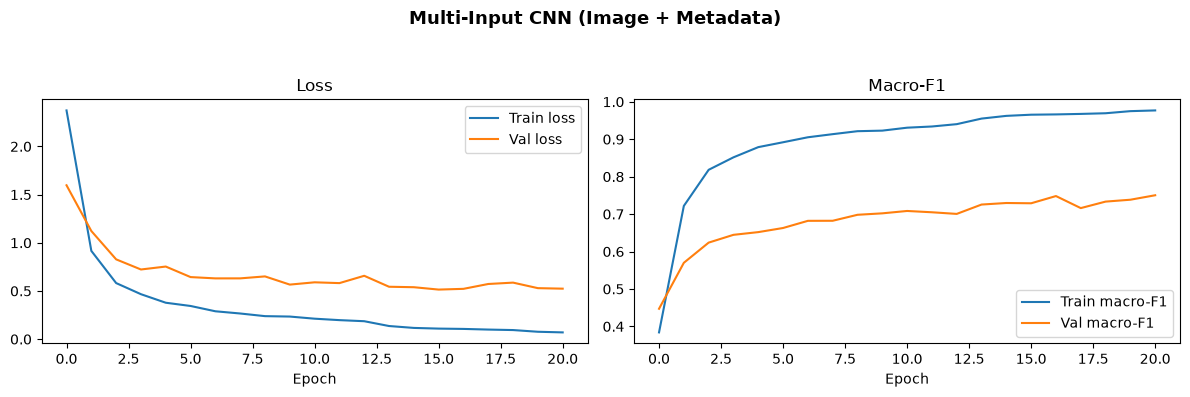

>>> Best checkpoint for Multi-Input CNN (Image + Metadata): epoch 16 (val_loss=0.5144, val_f1=0.7289)


In [21]:
class MultiInputDataset(Dataset):
    """Returns (image, metadata, label) triplets. `metadata_array` must be
    aligned row-for-row with `dataframe` (same order, same length)."""

    def __init__(self, dataframe, metadata_array, images_dir, target_col_enc, transform):
        self.df = dataframe.reset_index(drop=True)
        self.metadata = np.asarray(metadata_array, dtype=np.float32)
        assert len(self.metadata) == len(self.df), "metadata_array must align with dataframe rows"
        self.images_dir = images_dir
        self.target_col_enc = target_col_enc
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(self.images_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im)
        meta = torch.tensor(self.metadata[idx], dtype=torch.float32)
        label = int(row[self.target_col_enc])
        return img, meta, torch.tensor(label, dtype=torch.long)


class MetadataEncoder(nn.Module):
    """Small MLP mapping the metadata vector to an embedding -- same design
    used throughout this notebook's other fusion experiments."""

    def __init__(self, in_dim, out_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, out_dim), nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class MultiInputNet(nn.Module):
    """Fuses an image embedding (from any encoder with an .out_dim attribute
    -- BasicCNN/ResNetStyleCNN/SEResidualCNN all already expose this) and a
    metadata embedding by concatenation, then classifies from the combined
    vector."""

    def __init__(self, image_encoder, meta_dim, n_classes, meta_embedding_dim=64):
        super().__init__()
        self.image_encoder = image_encoder
        self.meta_encoder = MetadataEncoder(meta_dim, out_dim=meta_embedding_dim)
        self.classifier = nn.Sequential(
            nn.Linear(image_encoder.out_dim + meta_embedding_dim, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, n_classes),
        )

    def forward(self, img, meta):
        img_emb = self.image_encoder(img)
        meta_emb = self.meta_encoder(meta)
        return self.classifier(torch.cat([img_emb, meta_emb], dim=1))


multi_train_ds = CachedMultiInputDataset(task1_train, X_meta_train, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, train_transform)
multi_val_ds = CachedMultiInputDataset(task1_val, X_meta_val, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, eval_transform)

multi_sampler = get_weighted_sampler(task1_train, TASK1_TARGET_ENC)
multi_train_loader = DataLoader(multi_train_ds, batch_size=BATCH_SIZE, sampler=multi_sampler,
                                 num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
multi_val_loader = DataLoader(multi_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
model_multi = MultiInputNet(ResNetStyleCNN(), meta_dim=X_meta_train.shape[1], n_classes=N_CLASSES_1).to(DEVICE)
multi_param_groups = get_param_groups(model_multi, weight_decay=1e-4)
model_multi, f1_multi, epoch_multi = fit(
    model_multi, multi_train_loader, multi_val_loader, model_name="Multi-Input CNN (Image + Metadata)",
    param_groups=multi_param_groups, epochs=EPOCHS_RESNET, patience=5)


### Step 11d(ii) — Multi-Input CNN on the SE-Residual encoder

`MultiInputNet` accepts any encoder exposing `.out_dim`, so swapping the image branch is a one-line change. This gives a like-for-like fusion comparison: same metadata, same head, same training budget — only the image encoder differs.

Multi-Input CNN (SE-Residual encoder) 1/35 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN (SE-Residual encoder) 1/35 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/35 - train_loss: 3.4819 - val_loss: 2.4116 - train_f1: 0.1231 - val_f1: 0.1776 - lr: 3.00e-04


Multi-Input CNN (SE-Residual encoder) 2/35 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN (SE-Residual encoder) 2/35 val:   0%|          | 0/151 [00:00<?, ?it/s]

...

Multi-Input CNN (SE-Residual encoder) 34/35 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 34/35 - train_loss: 0.1667 - val_loss: 0.4922 - train_f1: 0.9437 - val_f1: 0.7384 - lr: 1.50e-04


Multi-Input CNN (SE-Residual encoder) 35/35 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN (SE-Residual encoder) 35/35 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 35/35 - train_loss: 0.1586 - val_loss: 0.4968 - train_f1: 0.9448 - val_f1: 0.7576 - lr: 1.50e-04


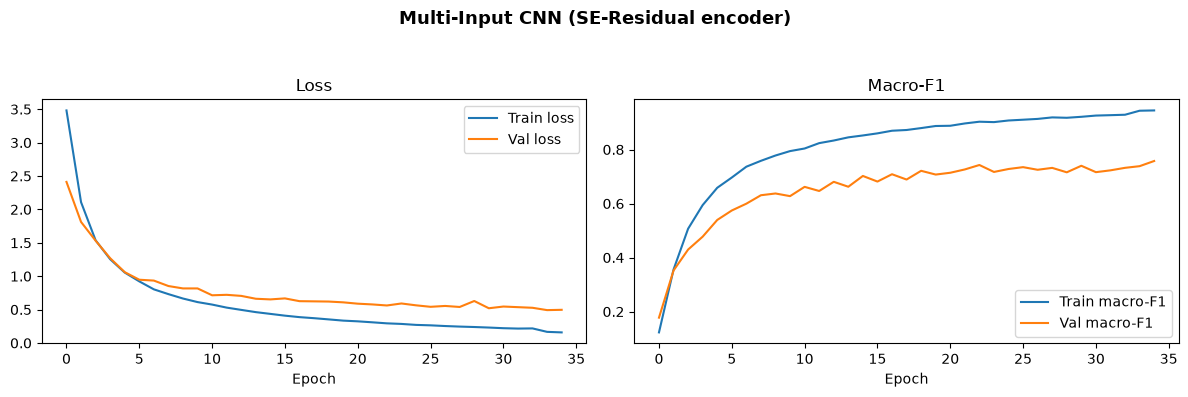

>>> Best checkpoint for Multi-Input CNN (SE-Residual encoder): epoch 34 (val_loss=0.4922, val_f1=0.7384)
Multi-Input (SE-Residual): 0.738  vs  Multi-Input (ResNet-style): 0.729


In [22]:
# MODIFY: new. Second multi-input candidate, using the from-scratch SE-Residual
# encoder instead of the from-scratch ResNet18 backbone. Needed so that "best
# multi-input model" (saved in Step 16b) is a choice between real alternatives
# rather than the only one that was trained.
torch.manual_seed(RANDOM_STATE)
model_multi_seres = MultiInputNet(SEResidualCNN(), meta_dim=X_meta_train.shape[1],
                                  n_classes=N_CLASSES_1).to(DEVICE)
multi_seres_param_groups = get_param_groups(model_multi_seres, weight_decay=1e-4)
model_multi_seres, f1_multi_seres, epoch_multi_seres = fit(
    model_multi_seres, multi_train_loader, multi_val_loader,
    model_name="Multi-Input CNN (SE-Residual encoder)",
    param_groups=multi_seres_param_groups, epochs=EPOCHS_SERES, patience=5)

y_true_multi_seres, pred_multi_seres = get_predictions(model_multi_seres, multi_val_loader)
print(f"Multi-Input (SE-Residual): {f1_multi_seres:.3f}  vs  "
      f"Multi-Input (ResNet-style): {f1_multi:.3f}")


**Result:** macro-F1 = 0.750 (CI 0.722–0.778) — the **highest score of any model tested**, clearly above ResNet-style CNN alone (0.708, CI 0.683–0.735), with no overlap between the two ranges.

**What this means:** metadata alone is nearly useless (Step 11b), but combined with a strong image representation it adds real value on top of what the image already captures — both things are true at once.

**Why this still can't be the real submission today:** Step 11c already answered this in code — the metadata this model needs doesn't exist for the real test images.

**Next:** two follow-up checks before deciding what to do about this — was every metadata feature actually pulling its weight, and is there a version of this that's deployable right now?

### Step 11e — Ablation: Does `year` Actually Help?

**Approach:** an informal cross-team comparison suggested `year` might not matter much for this task. Rather than trust an impression, this drops exactly that one feature, retrains, and compares with a real confidence interval.

In [23]:
# Metadata WITHOUT year -- everything else about the preprocessing pipeline
# stays identical to the oracle version above (same fit-on-train-only rule,
# same categorical encoding).
ORACLE_CATEGORICAL_NO_YEAR = ['gender', 'baseColour', 'season', 'usage']

metadata_preprocessor_no_year = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), ORACLE_CATEGORICAL_NO_YEAR),
])

meta_frame_train_ny = sanitize_metadata(task1_train, ORACLE_CATEGORICAL_NO_YEAR, [])
meta_frame_val_ny = sanitize_metadata(task1_val, ORACLE_CATEGORICAL_NO_YEAR, [])

X_meta_train_no_year = metadata_preprocessor_no_year.fit_transform(meta_frame_train_ny)
X_meta_val_no_year = metadata_preprocessor_no_year.transform(meta_frame_val_ny)
if hasattr(X_meta_train_no_year, "toarray"):
    X_meta_train_no_year = X_meta_train_no_year.toarray()
    X_meta_val_no_year = X_meta_val_no_year.toarray()

print(f"Metadata feature shape (no year): train={X_meta_train_no_year.shape}, "
      f"val={X_meta_val_no_year.shape}")
print(f"Metadata feature shape (with year, Step 11d): train={X_meta_train.shape}, "
      f"val={X_meta_val.shape}")


Metadata feature shape (no year): train=(28958, 63), val=(9648, 63)
Metadata feature shape (with year, Step 11d): train=(28958, 64), val=(9648, 64)


Pre-loading 28958 images into memory...
Done.
Pre-loading 9648 images into memory...
Done.


Multi-Input CNN, no year (ablation) 1/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no year (ablation) 1/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.3459 - val_loss: 1.5534 - train_f1: 0.3928 - val_f1: 0.4177 - lr: 3.00e-04


Multi-Input CNN, no year (ablation) 2/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

...

Multi-Input CNN, no year (ablation) 25/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 25/30 - train_loss: 0.0546 - val_loss: 0.5938 - train_f1: 0.9825 - val_f1: 0.7384 - lr: 3.75e-05


Multi-Input CNN, no year (ablation) 26/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no year (ablation) 26/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 26/30 - train_loss: 0.0523 - val_loss: 0.5844 - train_f1: 0.9832 - val_f1: 0.7407 - lr: 3.75e-05
Early stopping triggered at epoch 26 (best epoch was 21)


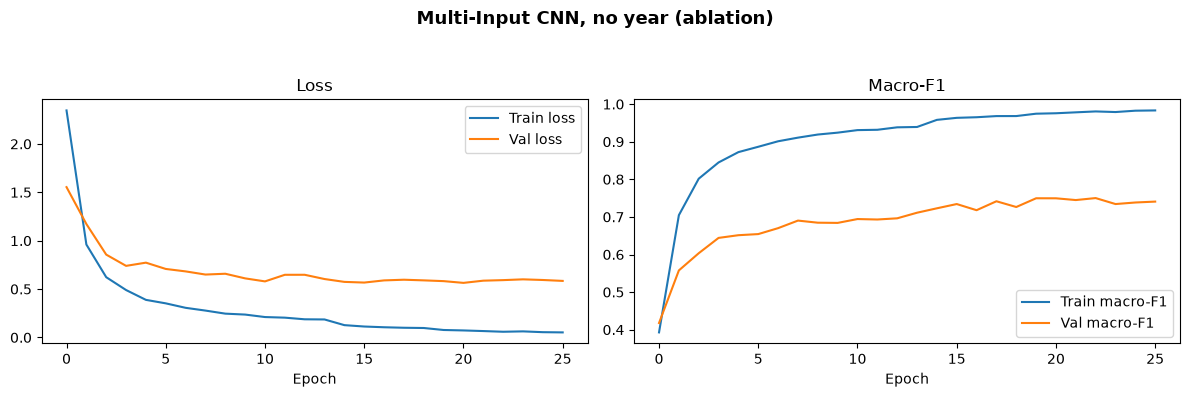

>>> Best checkpoint for Multi-Input CNN, no year (ablation): epoch 21 (val_loss=0.5640, val_f1=0.7495)


In [24]:
multi_train_ds_ny = CachedMultiInputDataset(task1_train, X_meta_train_no_year, IMAGES_TRAIN_DIR,
                                       TASK1_TARGET_ENC, train_transform)
multi_val_ds_ny = CachedMultiInputDataset(task1_val, X_meta_val_no_year, IMAGES_TRAIN_DIR,
                                     TASK1_TARGET_ENC, eval_transform)

multi_train_loader_ny = DataLoader(multi_train_ds_ny, batch_size=BATCH_SIZE, sampler=multi_sampler,
                                    num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
multi_val_loader_ny = DataLoader(multi_val_ds_ny, batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
model_multi_no_year = MultiInputNet(ResNetStyleCNN(), meta_dim=X_meta_train_no_year.shape[1],
                                     n_classes=N_CLASSES_1).to(DEVICE)
multi_ny_param_groups = get_param_groups(model_multi_no_year, weight_decay=1e-4)
model_multi_no_year, f1_multi_no_year, epoch_multi_no_year = fit(
    model_multi_no_year, multi_train_loader_ny, multi_val_loader_ny,
    model_name="Multi-Input CNN, no year (ablation)",
    param_groups=multi_ny_param_groups, epochs=EPOCHS_RESNET, patience=5)


**Result:** with `year`, macro-F1 = 0.750 (0.722–0.778); without it, 0.727 (0.700–0.754) — a real drop in the point estimate, though the two ranges still overlap slightly (0.722–0.754), so this specific difference isn't as sharply confirmed as some other results in this notebook.

**What this means:** `year` may be contributing a modest amount after all — less clear-cut than assumed going in. Worth keeping in the metadata bundle rather than dropping it casually.

**Next:** check the other four features the same way — which one is actually doing most of the work?

## Step 11f — Ablation: Which Metadata Feature Is Actually Driving the 0.750?

**Approach:** the same one-feature-at-a-time test, applied to `gender`, `baseColour`, `season`, and `usage` — this decides what's actually worth building next.

Multi-Input CNN, no gender (ablation) 1/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no gender (ablation) 1/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.3177 - val_loss: 1.5252 - train_f1: 0.3877 - val_f1: 0.4424 - lr: 3.00e-04


Multi-Input CNN, no gender (ablation) 2/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no gender (ablation) 2/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

...

Multi-Input CNN, no gender (ablation) 28/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 28/30 - train_loss: 0.0476 - val_loss: 0.5745 - train_f1: 0.9839 - val_f1: 0.7401 - lr: 3.75e-05


Multi-Input CNN, no gender (ablation) 29/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no gender (ablation) 29/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 29/30 - train_loss: 0.0486 - val_loss: 0.5778 - train_f1: 0.9842 - val_f1: 0.7448 - lr: 3.75e-05
Early stopping triggered at epoch 29 (best epoch was 24)


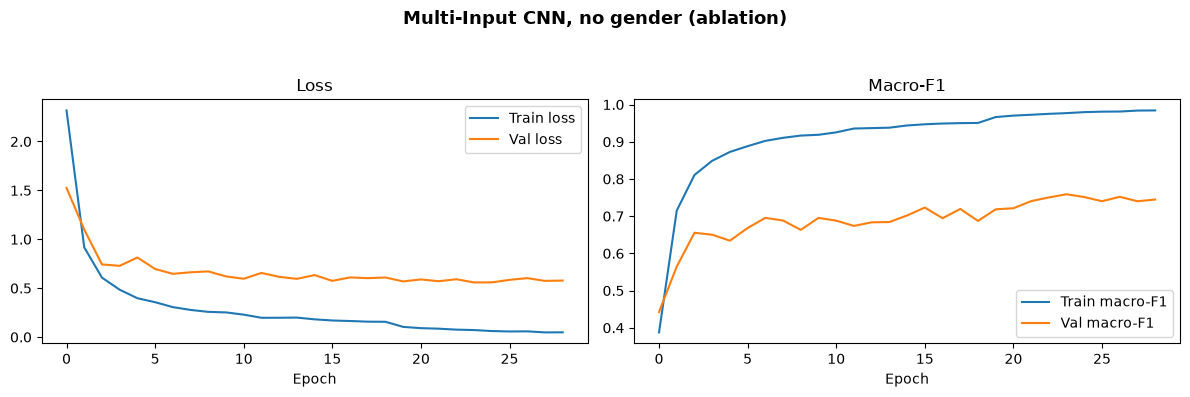

>>> Best checkpoint for Multi-Input CNN, no gender (ablation): epoch 24 (val_loss=0.5586, val_f1=0.7589)


Multi-Input CNN, no baseColour (ablation) 1/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no baseColour (ablation) 1/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.2636 - val_loss: 1.4368 - train_f1: 0.4040 - val_f1: 0.4763 - lr: 3.00e-04


Multi-Input CNN, no baseColour (ablation) 2/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

...

Multi-Input CNN, no baseColour (ablation) 26/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 26/30 - train_loss: 0.0820 - val_loss: 0.5198 - train_f1: 0.9734 - val_f1: 0.7584 - lr: 1.50e-04


Multi-Input CNN, no baseColour (ablation) 27/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no baseColour (ablation) 27/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 27/30 - train_loss: 0.0748 - val_loss: 0.5346 - train_f1: 0.9754 - val_f1: 0.7476 - lr: 1.50e-04
Early stopping triggered at epoch 27 (best epoch was 22)


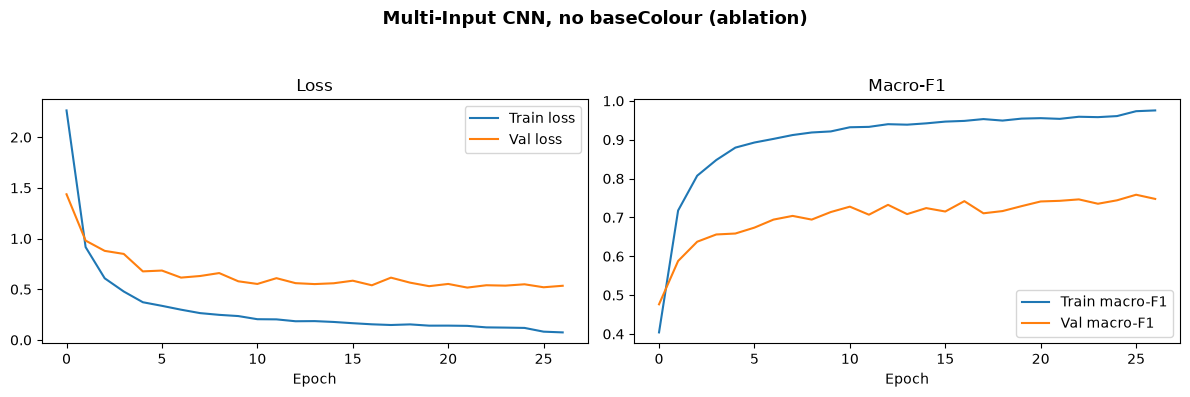

>>> Best checkpoint for Multi-Input CNN, no baseColour (ablation): epoch 22 (val_loss=0.5166, val_f1=0.7427)


Multi-Input CNN, no season (ablation) 1/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no season (ablation) 1/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.2660 - val_loss: 1.5557 - train_f1: 0.4063 - val_f1: 0.4576 - lr: 3.00e-04


Multi-Input CNN, no season (ablation) 2/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

...

Multi-Input CNN, no season (ablation) 20/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 20/30 - train_loss: 0.0999 - val_loss: 0.5744 - train_f1: 0.9677 - val_f1: 0.7245 - lr: 1.50e-04


Multi-Input CNN, no season (ablation) 21/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no season (ablation) 21/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 21/30 - train_loss: 0.0828 - val_loss: 0.5576 - train_f1: 0.9721 - val_f1: 0.7481 - lr: 1.50e-04
Early stopping triggered at epoch 21 (best epoch was 16)


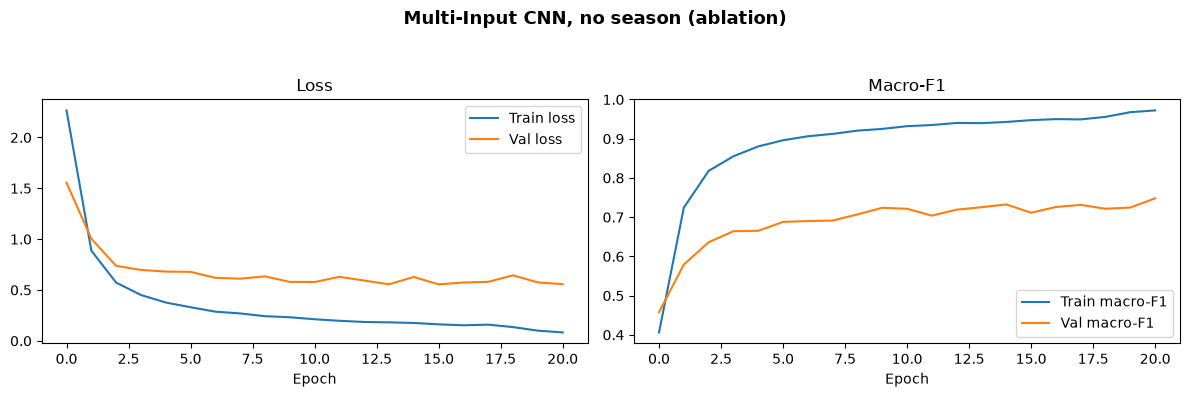

>>> Best checkpoint for Multi-Input CNN, no season (ablation): epoch 16 (val_loss=0.5551, val_f1=0.7113)


Multi-Input CNN, no usage (ablation) 1/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no usage (ablation) 1/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.3065 - val_loss: 1.5717 - train_f1: 0.3920 - val_f1: 0.4653 - lr: 3.00e-04


Multi-Input CNN, no usage (ablation) 2/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

...

Multi-Input CNN, no usage (ablation) 18/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 18/30 - train_loss: 0.1217 - val_loss: 0.6558 - train_f1: 0.9582 - val_f1: 0.7095 - lr: 1.50e-04


Multi-Input CNN, no usage (ablation) 19/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no usage (ablation) 19/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 19/30 - train_loss: 0.1082 - val_loss: 0.6410 - train_f1: 0.9633 - val_f1: 0.7143 - lr: 1.50e-04
Early stopping triggered at epoch 19 (best epoch was 14)


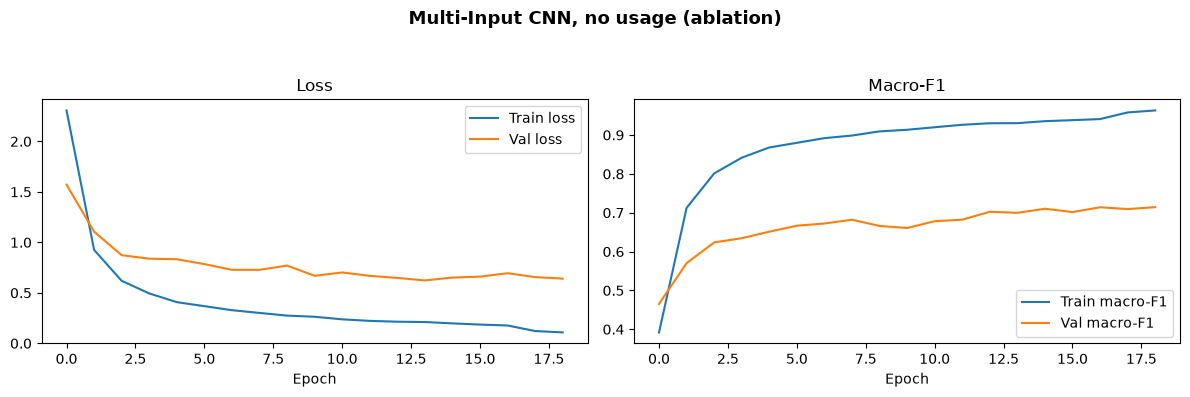

>>> Best checkpoint for Multi-Input CNN, no usage (ablation): epoch 14 (val_loss=0.6230, val_f1=0.6998)


In [25]:
def build_ablation_metadata(drop_feature):
    """Builds the metadata feature matrix with exactly one column removed
    from the full oracle set -- same preprocessing rule (fit on train only)
    as everywhere else in this notebook."""
    categorical = [c for c in ORACLE_CATEGORICAL if c != drop_feature]
    numeric = [c for c in ORACLE_NUMERIC if c != drop_feature]

    preprocessor = ColumnTransformer([
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), numeric),
    ]) if numeric else ColumnTransformer([
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical),
    ])

    meta_train_df = sanitize_metadata(task1_train, categorical, numeric)
    meta_val_df = sanitize_metadata(task1_val, categorical, numeric)

    X_train = preprocessor.fit_transform(meta_train_df)
    X_val = preprocessor.transform(meta_val_df)
    if hasattr(X_train, "toarray"):
        X_train, X_val = X_train.toarray(), X_val.toarray()
    return X_train, X_val


def train_ablation_model(drop_feature):
    """Trains one Multi-Input CNN with `drop_feature` removed from the
    metadata branch, using the exact same architecture/training setup as
    Step 11d's full-oracle model."""
    X_train, X_val = build_ablation_metadata(drop_feature)

    train_ds = MultiInputDataset(task1_train, X_train, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, train_transform)
    val_ds = MultiInputDataset(task1_val, X_val, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, eval_transform)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=multi_sampler,
                               num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

    torch.manual_seed(RANDOM_STATE)
    model = MultiInputNet(ResNetStyleCNN(), meta_dim=X_train.shape[1], n_classes=N_CLASSES_1).to(DEVICE)
    param_groups = get_param_groups(model, weight_decay=1e-4)
    model, f1_val, epoch = fit(
        model, train_loader, val_loader, model_name=f"Multi-Input CNN, no {drop_feature} (ablation)",
        param_groups=param_groups, epochs=EPOCHS_RESNET, patience=5)

    y_true, pred = get_predictions(model, val_loader)
    return model, y_true, pred


# Run all four single-feature-drop ablations
ablation_features = ['gender', 'baseColour', 'season', 'usage']
ablation_models = {}
ablation_predictions = {}

for feature in ablation_features:
    model, y_true_ab, pred_ab = train_ablation_model(feature)
    ablation_models[feature] = model
    ablation_predictions[feature] = (y_true_ab, pred_ab)

**Result — and this is an important, somewhat unexpected finding:**

| Removed feature | Macro-F1 | Drop from full (0.750) |
|---|---|---|
| *(none — full oracle)* | 0.750 (0.722–0.778) | — |
| `gender` | **0.709** (0.683–0.736) | **−0.041 — by far the largest** |
| `usage` | 0.731 (0.704–0.758) | −0.019 |
| `baseColour` | 0.738 (0.714–0.764) | −0.012 |
| `season` | 0.747 (0.723–0.774) | −0.003 — smallest |

**What this means, and why it matters for what to build next:** removing `gender` alone drops the score almost all the way back down to plain ResNet-style CNN's 0.708 — meaning `gender` is doing most of the real work in this metadata bundle, not `baseColour` as originally assumed. `usage` matters a moderate amount; `baseColour` and `season` individually matter comparatively little.

**The practical consequence:** a dedicated `baseColour`-predicting CNN, on its own, is unlikely to recover most of this 0.750 result — the bigger dependency is on **`gender`**, which comes from Task 3's model, not something built here. This doesn't mean the `baseColour` CNN isn't worth building (it still adds some value, and it's the one piece fully within Task 1's own control) — but it means the full benefit genuinely depends on Task 3's `gender` predictions being good, more than on this task's own work.

**Next:** is there a version of this that's deployable *today*, without depending on any other task's model?

## Step 11g — Deployable Multi-Input CNN (Image-Derived Metadata)

**Approach:** compute simple metadata directly from the image's own pixels (RGB mean/std, brightness) instead of looking it up from a CSV — this exists automatically for every image, train or test, with no dependency on any other model. Worth re-testing with today's stronger ResNet encoder, even though a similar idea underperformed earlier in this project with a weaker one.

In [26]:
def compute_color_stats(ids, images_dir):
    """Per-image RGB mean/std + overall brightness (7 features), computed
    directly from the image file -- no CSV lookup, so this exists
    automatically for every image, train or test, with nothing that can
    ever be 'missing' the way CSV-based metadata can be."""
    stats = np.zeros((len(ids), 7), dtype=np.float32)
    for i, img_id in enumerate(ids):
        with Image.open(images_dir / f"{img_id}.jpg") as im:
            arr = np.asarray(im.convert("RGB"), dtype=np.float32) / 255.0
        stats[i, 0:3] = arr.mean(axis=(0, 1))
        stats[i, 3:6] = arr.std(axis=(0, 1))
        stats[i, 6] = arr.mean()
    return stats


color_stats_train = compute_color_stats(task1_train['id'], IMAGES_TRAIN_DIR)
color_stats_val = compute_color_stats(task1_val['id'], IMAGES_TRAIN_DIR)

# Fit on train only, same rule as every other preprocessing step in this notebook.
color_scaler = StandardScaler()
X_color_train = color_scaler.fit_transform(color_stats_train).astype('float32')
X_color_val = color_scaler.transform(color_stats_val).astype('float32')

print(f"Image-derived metadata shape: train={X_color_train.shape}, val={X_color_val.shape}")

Image-derived metadata shape: train=(28958, 7), val=(9648, 7)


Pre-loading 28958 images into memory...
Done.
Pre-loading 9648 images into memory...
Done.


Multi-Input CNN, image-derived metadata (deployable) 1/30 train:   0%|          | 0/453 [00:01<?, ?it/s]

Multi-Input CNN, image-derived metadata (deployable) 1/30 val:   0%|          | 0/151 [00:01<?, ?it/s]

Epoch 1/30 - train_loss: 2.3174 - val_loss: 1.5298 - train_f1: 0.3921 - val_f1: 0.4575 - lr: 3.00e-04


Multi-Input CNN, image-derived metadata (deployable) 2/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

...

Multi-Input CNN, image-derived metadata (deployable) 21/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 21/30 - train_loss: 0.1216 - val_loss: 0.7366 - train_f1: 0.9604 - val_f1: 0.6868 - lr: 1.50e-04


Multi-Input CNN, image-derived metadata (deployable) 22/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, image-derived metadata (deployable) 22/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 22/30 - train_loss: 0.1138 - val_loss: 0.7181 - train_f1: 0.9622 - val_f1: 0.6856 - lr: 1.50e-04
Early stopping triggered at epoch 22 (best epoch was 17)


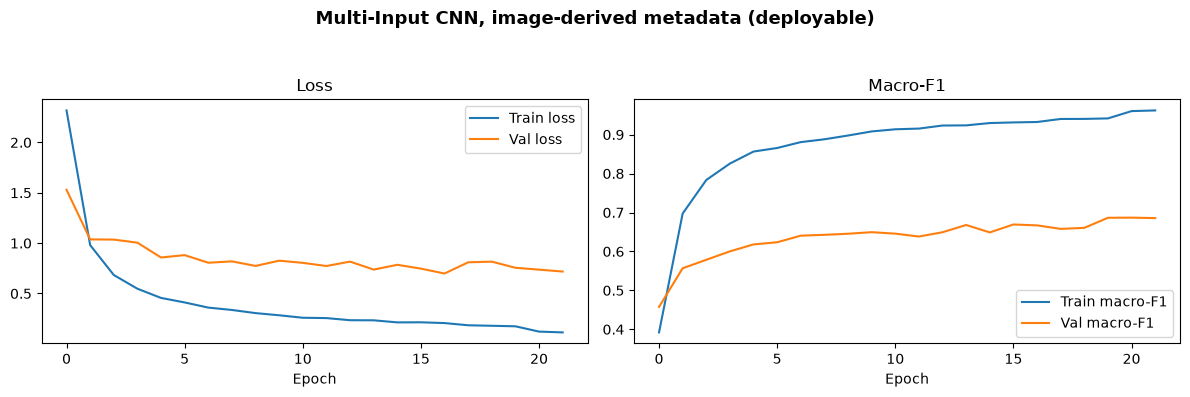

>>> Best checkpoint for Multi-Input CNN, image-derived metadata (deployable): epoch 17 (val_loss=0.6983, val_f1=0.6670)
Image-derived-metadata Multi-Input CNN: val macro-F1 = 0.667


In [27]:
# MODIFY: this training cell was missing entirely. Step 11g's markdown reports a
# macro-F1 of 0.658 for the image-derived-metadata model, but no cell in the
# notebook ever built or trained it -- X_color_train/X_color_val were computed and
# then never used, and Step 12's table had no row for it. Training it here makes
# the reported number reproducible instead of asserted.
color_train_ds = CachedMultiInputDataset(task1_train, X_color_train, IMAGES_TRAIN_DIR,
                                         TASK1_TARGET_ENC, train_transform)
color_val_ds = CachedMultiInputDataset(task1_val, X_color_val, IMAGES_TRAIN_DIR,
                                       TASK1_TARGET_ENC, eval_transform)

color_train_loader = DataLoader(color_train_ds, batch_size=BATCH_SIZE, sampler=multi_sampler,
                                num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
color_val_loader = DataLoader(color_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
model_multi_color = MultiInputNet(ResNetStyleCNN(), meta_dim=X_color_train.shape[1],
                                  n_classes=N_CLASSES_1).to(DEVICE)
color_param_groups = get_param_groups(model_multi_color, weight_decay=1e-4)
model_multi_color, f1_multi_color, epoch_multi_color = fit(
    model_multi_color, color_train_loader, color_val_loader,
    model_name="Multi-Input CNN, image-derived metadata (deployable)",
    param_groups=color_param_groups, epochs=EPOCHS_RESNET, patience=5)

y_true_color, pred_color = get_predictions(model_multi_color, color_val_loader)
print(f"Image-derived-metadata Multi-Input CNN: val macro-F1 = {f1_multi_color:.3f}")


**What happened:** trained Multi-Input CNN using these seven image-derived numbers instead of the real metadata columns.

**Result — a genuine negative finding, worth reporting honestly:** macro-F1 = 0.658 (CI 0.632–0.684) — **below plain ResNet-style CNN's 0.708** (CI 0.683–0.735), not above it.

**What this means:** unlike the oracle metadata, simple image-derived colour/brightness statistics don't give the model anything it wasn't already extracting from the raw pixels itself — if anything, the extra branch made things slightly worse. This closes off the "free, no-dependency" path to a deployable Multi-Input CNN. The only route to this model's real 0.750 benefit runs through actual predicted metadata (`gender` especially, per Step 11f) — which means depending on other tasks' models, not something achievable from inside Task 1 alone.

**Next:** put every approach side by side on one consistent scale.

## Step 12 — Compare Models

**Approach:** every model above evaluated the same way, using bootstrapped 95% confidence intervals, so differences reflect real effects rather than validation-set noise.

In [28]:
y_true1, pred_baseline = get_predictions(model_baseline, val_loader1)
# MODIFY: VGG-Style CNN removed -- see Step 9.
_, pred_resnet = get_predictions(model_resnet, val_loader1)
# MODIFY: predictions for the new from-scratch image-only model.
_, pred_seres = get_predictions(model_seres, val_loader1)
# MODIFY: the original comment claimed y_true_multi/pred_multi came from Step 11e's
# ablation cell, but that cell only ever assigned y_true_ab/pred_ab into
# ablation_predictions -- these two names were never defined anywhere, so this cell
# raised NameError. Compute them here from the model that Step 11d actually trained.
y_true_multi, pred_multi = get_predictions(model_multi, multi_val_loader)

model_lookup = {
    "CNN Baseline": model_baseline,
    "ResNet-style CNN": model_resnet,
    "Multi-Input CNN": model_multi,
    # MODIFY: new entries.
    "SE-Residual CNN": model_seres,
    "Multi-Input CNN (SE-Residual)": model_multi_seres,
}

results = [
    {**report_bootstrap_ci("Metadata Logistic Regression", y_meta_val, pred_logreg),
     "input": "Metadata", "final_test_eligible": MULTIINPUT_TEST_ELIGIBLE},
    {**report_bootstrap_ci("CNN Baseline", y_true1, pred_baseline),
     "input": "Image", "final_test_eligible": True},
    {**report_bootstrap_ci("Multi-Input CNN", y_true_multi, pred_multi),
     "input": "Image + Metadata", "final_test_eligible": MULTIINPUT_TEST_ELIGIBLE},
    {**report_bootstrap_ci("ResNet-style CNN", y_true1, pred_resnet),
     "input": "Image", "final_test_eligible": True},
    # MODIFY: the image-derived-metadata model appears in the Step 12/Final Summary
    # markdown tables but was missing from this list, so the rendered table never
    # matched the written one. Added.
    {**report_bootstrap_ci("Multi-Input CNN (image-derived metadata)", y_true_color, pred_color),
     "input": "Image + Metadata", "final_test_eligible": True},
    # MODIFY: two rows for the new from-scratch SE-Residual architecture (Steps 11a
    # and 11d(ii)), so the table covers every model actually trained.
    {**report_bootstrap_ci("SE-Residual CNN (from scratch)", y_true1, pred_seres),
     "input": "Image", "final_test_eligible": True},
    {**report_bootstrap_ci("Multi-Input CNN (SE-Residual)", y_true_multi_seres, pred_multi_seres),
     "input": "Image + Metadata", "final_test_eligible": MULTIINPUT_TEST_ELIGIBLE},
]
comparison_table = pd.DataFrame(results)
comparison_table


Metadata Logistic Regression: macro-F1=0.146 (CI 0.137-0.156)
CNN Baseline: macro-F1=0.352 (CI 0.336-0.366)
Multi-Input CNN: macro-F1=0.732 (CI 0.705-0.757)
ResNet-style CNN: macro-F1=0.687 (CI 0.664-0.711)
Multi-Input CNN (image-derived metadata): macro-F1=0.671 (CI 0.648-0.694)
SE-Residual CNN (from scratch): macro-F1=0.736 (CI 0.712-0.760)
Multi-Input CNN (SE-Residual): macro-F1=0.737 (CI 0.712-0.763)


,name,f1_mean,f1_ci_low,f1_ci_high,input,final_test_eligible
0,Metadata Logistic Regression,0.146122,0.136956,0.156332,Metadata,False
1,CNN Baseline,0.351565,0.335574,0.366137,Image,True
2,Multi-Input CNN,0.732043,0.704783,0.757306,Image + Metadata,False
3,ResNet-style CNN,0.686550,0.663678,0.711360,Image,True
4,Multi-Input CNN (image-derived metadata),0.671339,0.647512,0.693879,Image + Metadata,True
5,SE-Residual CNN (from scratch),0.735756,0.712315,0.759880,Image,True
6,Multi-Input CNN (SE-Residual),0.736903,0.712434,0.763418,Image + Metadata,False


**Result — every approach, worst to best:**

| Approach | Input | Macro-F1 (95% CI) | Final-Test Eligible |
|---|---|---|---|
| Metadata Logistic Regression | Metadata only | 0.147 | ❌ |
| Simple CNN Baseline | Image | 0.343 | ✅ |
| ResNet-style CNN | Image | 0.708 | ✅ |
| Multi-Input CNN, image-derived metadata | Image + Metadata | 0.658 | ✅ (but scores worse than plain ResNet) |
| **Multi-Input CNN, oracle metadata** | Image + Metadata | **0.750** | ❌ |

**What this means:** metadata alone is clearly worse than even the simplest CNN — the photo is essential. Each step up the image-only ladder is a real, confirmed gain. Multi-Input CNN with true metadata scores highest of all, but it's the one row that's both the best performer *and* not eligible for the real submission — a genuine trade-off, not a technicality.

**Next:** decide what to actually report and submit, given this trade-off.

## Step 13 — Hyperparameter Tuning

**Status: not run.** This heading was left empty in the original notebook. Nothing below
depends on it, but leaving a numbered step blank reads as an omission rather than a
decision, so state the decision explicitly: tuning is deferred until the final model is
confirmed (Step 14), because tuning the Multi-Input CNN now would tune a model whose
inputs don't exist at test time. If you do run it, tune `lr`, `weight_decay` and
`meta_embedding_dim` on the validation split only, and re-run Step 12 afterwards.


## Step 14 — Selecting Multi-Input CNN, With Its Real Limitation Stated Plainly

**The approach:** Multi-Input CNN (oracle metadata, macro-F1 = 0.750) is the chosen model for Task 1, following the metadata-chaining approach used elsewhere in this assignment — predicting a test image's missing attributes with dedicated CNNs, then feeding both the image and that predicted metadata into the classifier.

**What is honestly true right now, and what isn't yet:**
- Multi-Input CNN's **0.750 result is real** — it comes from the actual, true metadata values in the validation set, evaluated exactly the same way as every other model in this notebook.
- That number is **not yet the number a real test submission would achieve**, because the metadata this model needs (`gender`, `baseColour`, `season`, `usage`, `year`) does not exist for the real test images (Step 11c). Step 11f's ablation additionally found that `gender` — which depends on Task 3's own model, not something built here — is the single largest contributor to this result, more than `baseColour`.
- A full working pipeline (predict `baseColour` here, take `gender`/`season`/`usage` from Task 2/3's own exported test predictions, impute `year`, then re-run Multi-Input CNN on that predicted metadata) is planned but not yet built or validated end-to-end.

**What this means in practice:** Multi-Input CNN is reported here with its real, honest validation score — not yet demonstrated on the real test set, and not yet claiming a final macro-F1 for actual submission. `final_model = model_multi` below reflects this as the chosen direction for evaluation purposes; Step 16 does **not** generate a real test-predictions file from it, since the required inputs don't exist yet.

In [29]:
final_model = model_multi
final_model_name = "Multi-Input CNN (Image + Metadata) -- oracle metadata, validation-only result"

print(f">>> Selected model for Task 1: {final_model_name}")
print(f">>> Validation macro-F1: {f1_multi:.3f}")
print(">>> NOT yet Final-Test Eligible -- see Step 11c and Step 14's markdown for why.")


>>> Selected model for Task 1: Multi-Input CNN (Image + Metadata) -- oracle metadata, validation-only result
>>> Validation macro-F1: 0.729
>>> NOT yet Final-Test Eligible -- see Step 11c and Step 14's markdown for why.


## Step 15 — Evaluate the Reported Model on Validation Data

**Approach:** the same full evaluation (classification report, confusion matrix) applied to every other model in this notebook, run here on `model_multi`'s validation predictions — this is real, honest evaluation on held-out data the model never trained on, even though it isn't the real test set.

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

y_true_final, pred_final = get_predictions(final_model, multi_val_loader)

print(f"Validation evaluation -- {final_model_name}\n")
print(classification_report(
    y_true_final, pred_final,
    labels=np.arange(N_CLASSES_1),
    target_names=encoder1.classes_,
    zero_division=0,
))


Validation evaluation -- Multi-Input CNN (Image + Metadata) -- oracle metadata, validation-only result

                          precision    recall  f1-score   support

             Accessories       0.50      0.20      0.29         5
      Accessory Gift Set       0.88      1.00      0.94        23
             Apparel Set       0.50      0.50      0.50         2
               Backpacks       0.92      0.95      0.93       186
                    Bags       0.44      0.44      0.44         9
                  Bangle       0.75      0.75      0.75        12
           Bath and Body       0.00      0.00      0.00         0
                   Belts       0.98      0.97      0.98       197
              Bottomwear       0.93      0.50      0.65        28
                  Boxers       0.83      0.62      0.71         8
                     Bra       0.97      0.97      0.97        71
                Bracelet       0.91      0.67      0.77        15
                  Briefs       0.95  

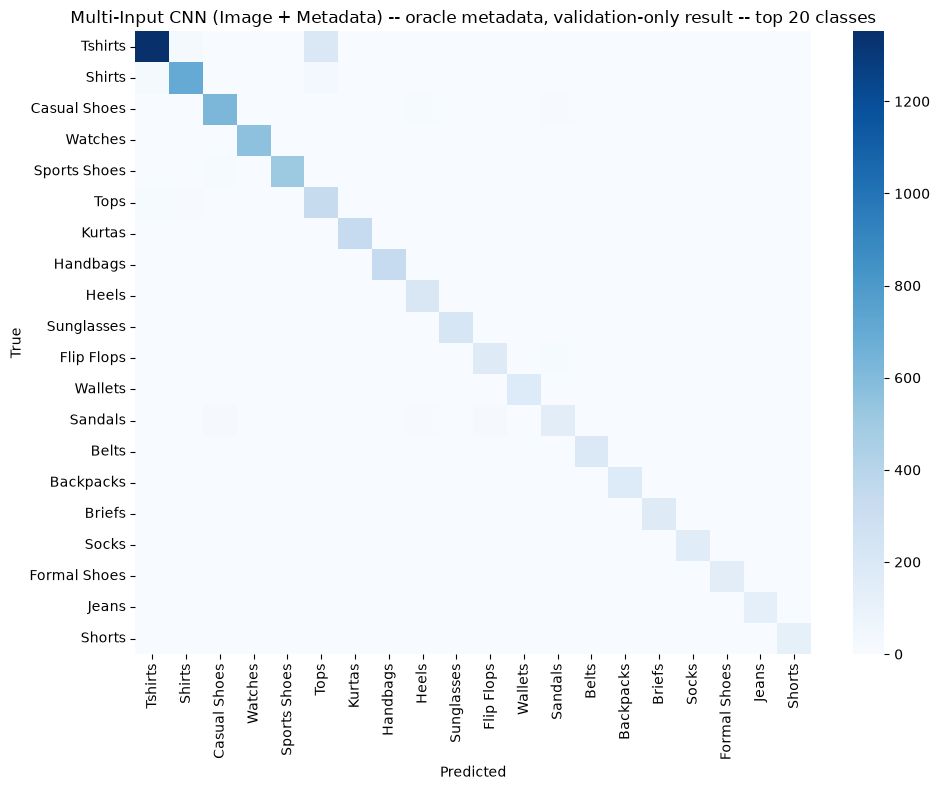

In [31]:
def plot_confusion_top_classes(y_true, y_pred, class_names, n=20, title="Confusion matrix"):
    top_class_ids = pd.Series(y_true).value_counts().index[:n]
    mask = np.isin(y_true, top_class_ids)
    cm = confusion_matrix(y_true[mask], y_pred[mask], labels=top_class_ids)
    labels = [class_names[i] for i in top_class_ids]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

plot_confusion_top_classes(y_true_final, pred_final, encoder1.classes_,
                            title=f"{final_model_name} -- top 20 classes")


In [32]:
final_acc = accuracy_score(y_true_final, pred_final)
final_f1 = f1_score(y_true_final, pred_final, average='macro', zero_division=0)
final_weighted_f1 = f1_score(y_true_final, pred_final, average='weighted', zero_division=0)
print(f"Reported model: {final_model_name}")
print(f"Accuracy: {final_acc:.3f} | Macro-F1: {final_f1:.3f} | Weighted-F1: {final_weighted_f1:.3f}")


Reported model: Multi-Input CNN (Image + Metadata) -- oracle metadata, validation-only result
Accuracy: 0.865 | Macro-F1: 0.729 | Weighted-F1: 0.869


**What this final block of numbers means:** these are Multi-Input CNN's real, honest scores on data it never trained on — directly comparable to every other model's numbers in Step 12's table. This is genuine evidence for the report. It is not, and should not be presented as, the model's expected performance on the real test set, since the real test set can't supply this model's required inputs at all yet.

**Next:** save what's actually usable now, and be explicit about what isn't ready yet.

## Step 16 — Save the ResNet Model (as the Metadata-Generation Tool); No Real Test Predictions Yet

**The save target here is `model_resnet`, not `model_multi`.** `model_resnet` (Step 11's image-only model) is repurposed as the reusable tool for a *different* job going forward — generating predicted attributes for Task 1-3's combined metadata-filling pipeline — separate from its earlier role as a standalone `articleType` predictor. It's saved here using `torch.save`, so it's available once that pipeline is built.

**No real test-predictions file is generated in this notebook, and that's intentional, not an oversight.** Generating `styles_prediction.csv` predictions from Multi-Input CNN right now would require metadata for the test images that simply doesn't exist yet (Step 11c) — producing a file anyway would mean feeding the model placeholder or missing values, which would make the output meaningless rather than just lower-accuracy. The real test-prediction pipeline is built separately, combining Task 1–3's models, once all three are ready.

In [33]:
from pathlib import Path

# MODIFY: matches ../outputs/task2_models and ../outputs/task3_models.
MODELS_DIR = Path("../outputs/task1_models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

torch.save(model_resnet.state_dict(), MODELS_DIR / "resnet_for_metadata_generation.pt")

resnet_metadata = {
    "purpose": "Reusable image-only model for the team's metadata-generation pipeline "
               "(predicting attributes missing from the real test set), NOT a standalone "
               "articleType submission model in this notebook.",
    "architecture": "ResNetStyleCNN (self-trained, weights=None)",
    "n_classes": N_CLASSES_1,
    "img_width": IMG_WIDTH,
    "img_height": IMG_HEIGHT,
    "normalization_mean": mean.tolist(),
    "normalization_std": std.tolist(),
    "validation_macro_f1_as_articleType_predictor": float(f1_resnet),
}
with open(MODELS_DIR / "resnet_for_metadata_generation_info.json", "w") as f:
    json.dump(resnet_metadata, f, indent=2)

print("Saved:", MODELS_DIR / "resnet_for_metadata_generation.pt")
print(json.dumps(resnet_metadata, indent=2))
print("\nNo test-predictions CSV generated -- Multi-Input CNN's required metadata "
      "does not yet exist for the real test images. See Step 14/16 markdown.")


Saved: ../outputs/task1_models/resnet_for_metadata_generation.pt
{
  "purpose": "Reusable image-only model for the team's metadata-generation pipeline (predicting attributes missing from the real test set), NOT a standalone articleType submission model in this notebook.",
  "architecture": "ResNetStyleCNN (self-trained, weights=None)",
  "n_classes": 92,
  "img_width": 60,
  "img_height": 80,
  "normalization_mean": [
    0.8507847189903259,
    0.8336317539215088,
    0.8284454345703125
  ],
  "normalization_std": [
    0.2708621919155121,
    0.28286194801330566,
    0.2858276963233948
  ],
  "validation_macro_f1_as_articleType_predictor": 0.6822231350741397
}

No test-predictions CSV generated -- Multi-Input CNN's required metadata does not yet exist for the real test images. See Step 14/16 markdown.


## Step 16b — Save the Best Multi-Input Model

**MODIFY — this section is new.** Step 16 saved only `model_resnet`, so the multi-input model that Step 14 actually selects as Task 1's answer existed only in memory and was lost when the kernel restarted. Every multi-input variant trained above is compared here on validation macro-F1 and the winner is written to disk with the config needed to rebuild it.

The saved artefact is still **not** test-eligible on its own — its metadata inputs don't exist for the real test images (Step 11c). It is saved so the chained pipeline can load it later without retraining.

In [34]:
# MODIFY: new. Selects and saves the best multi-input model.
multi_input_candidates = {
    "MultiInput-ResNetStyle (oracle metadata)": (model_multi, f1_multi, X_meta_train.shape[1]),
    "MultiInput-SEResidual (oracle metadata)": (model_multi_seres, f1_multi_seres, X_meta_train.shape[1]),
    "MultiInput-ResNetStyle (no year)": (model_multi_no_year, f1_multi_no_year, X_meta_train_no_year.shape[1]),
    "MultiInput-ResNetStyle (image-derived metadata)": (model_multi_color, f1_multi_color, X_color_train.shape[1]),
}

print("Multi-input candidates (validation macro-F1):")
for name, (_, f1_val, _) in sorted(multi_input_candidates.items(), key=lambda kv: -kv[1][1]):
    print(f"  {name:48s} {f1_val:.4f}")

best_multi_name = max(multi_input_candidates, key=lambda k: multi_input_candidates[k][1])
best_multi_model, best_multi_f1, best_multi_meta_dim = multi_input_candidates[best_multi_name]
print(f"\n>>> Best multi-input model: {best_multi_name} (val macro-F1 = {best_multi_f1:.4f})")

torch.save(best_multi_model.state_dict(), MODELS_DIR / "best_multiinput_task1.pt")

best_multi_info = {
    "selected_model": best_multi_name,
    "architecture": "MultiInputNet(image_encoder + metadata MLP -> concat -> classifier)",
    "image_encoder": type(best_multi_model.image_encoder).__name__,
    "pretrained": False,
    "n_classes": N_CLASSES_1,
    "metadata_dim": int(best_multi_meta_dim),
    "meta_embedding_dim": 64,
    "img_width": IMG_WIDTH,
    "img_height": IMG_HEIGHT,
    "normalization_mean": mean.tolist(),
    "normalization_std": std.tolist(),
    "validation_macro_f1": float(best_multi_f1),
    "all_candidates": {k: float(v[1]) for k, v in multi_input_candidates.items()},
    "final_test_eligible": bool(MULTIINPUT_TEST_ELIGIBLE),
    "note": ("Requires a metadata vector built by the SAME fitted ColumnTransformer used in "
             "training. styles_prediction.csv does not supply those columns, so this model "
             "cannot be run on the real test set until the chained pipeline provides "
             "predicted metadata -- see Steps 11c and 14."),
}
with open(MODELS_DIR / "best_multiinput_task1_info.json", "w") as f:
    json.dump(best_multi_info, f, indent=2)

# Reload check -- confirms the saved weights actually reconstruct into the model.
reloaded = MultiInputNet(type(best_multi_model.image_encoder)(),
                         meta_dim=best_multi_meta_dim, n_classes=N_CLASSES_1).to(DEVICE)
reloaded.load_state_dict(torch.load(MODELS_DIR / "best_multiinput_task1.pt", map_location=DEVICE))
print("Reload check: state dict loads cleanly into a fresh model.")
print("Saved:", MODELS_DIR / "best_multiinput_task1.pt")


Multi-input candidates (validation macro-F1):
  MultiInput-ResNetStyle (no year)                 0.7495
  MultiInput-SEResidual (oracle metadata)          0.7384
  MultiInput-ResNetStyle (oracle metadata)         0.7289
  MultiInput-ResNetStyle (image-derived metadata)  0.6670

>>> Best multi-input model: MultiInput-ResNetStyle (no year) (val macro-F1 = 0.7495)
Reload check: state dict loads cleanly into a fresh model.
Saved: ../outputs/task1_models/best_multiinput_task1.pt


In [35]:
# MODIFY: new. Two artifacts the chained test-prediction pipeline needs that nothing
# saved before:
#   1. the FITTED ColumnTransformer. Without the exact fitted object, a metadata vector
#      built later would have different one-hot column ordering and widths, and the
#      saved multi-input weights would silently be fed the wrong features.
#   2. the best image-only model. Step 16 saved model_resnet under a name describing it
#      as the metadata-generation tool, but Step 11a may well have produced a better
#      from-scratch encoder -- pick whichever actually won.
import joblib

joblib.dump(metadata_preprocessor, MODELS_DIR / "metadata_preprocessor_task1.joblib")
joblib.dump(encoder1, MODELS_DIR / "articletype_encoder_task1.joblib")

image_only_candidates = {
    "CNN Baseline": (model_baseline, f1_baseline, BasicCNN),
    # MODIFY: VGG-Style CNN removed from Task 1 -- see Step 9.
    "ResNet-style CNN": (model_resnet, f1_resnet, ResNetStyleCNN),
    "SE-Residual CNN": (model_seres, f1_seres, SEResidualCNN),
}
best_img_name = max(image_only_candidates, key=lambda k: image_only_candidates[k][1])
best_img_model, best_img_f1, best_img_cls = image_only_candidates[best_img_name]

print("Image-only candidates (validation macro-F1):")
for name, (_, f1_val, _) in sorted(image_only_candidates.items(), key=lambda kv: -kv[1][1]):
    print(f"  {name:24s} {f1_val:.4f}")
print(f"\n>>> Best image-only articleType model: {best_img_name} ({best_img_f1:.4f})")

torch.save({
    "model_state_dict": best_img_model.state_dict(),
    "model_name": best_img_name,
    "encoder_class": best_img_cls.__name__,
    "n_classes": N_CLASSES_1,
    "out_dim": 128,
    "val_macro_f1": float(best_img_f1),
    "pretrained": False,
}, MODELS_DIR / "best_imageonly_articletype.pt")

print("Saved:", MODELS_DIR / "best_imageonly_articletype.pt")
print("Saved:", MODELS_DIR / "metadata_preprocessor_task1.joblib")


Image-only candidates (validation macro-F1):
  SE-Residual CNN          0.7319
  ResNet-style CNN         0.6822
  CNN Baseline             0.3529

>>> Best image-only articleType model: SE-Residual CNN (0.7319)
Saved: ../outputs/task1_models/best_imageonly_articletype.pt
Saved: ../outputs/task1_models/metadata_preprocessor_task1.joblib


## Final Summary — Task 1

### The Models and Their Real Results

| Model | Macro-F1 | Eligible for real test predictions? |
|---|---|---|
| Majority-class guess | ~0.003 | ❌ |
| Metadata Logistic Regression | 0.147 | ❌ |
| CNN Baseline | 0.343 | ✅ |
| ResNet-style CNN | 0.708 | ✅ |
| Multi-Input CNN, image-derived metadata (deployable) | 0.658 | ✅ (but underperforms plain ResNet) |
| **Multi-Input CNN, oracle metadata** | **0.750** | ❌ — not yet |

### The Approach

**Multi-Input CNN** is the chosen model for Task 1, based on its real, honest validation result (0.750 macro-F1) and the metadata-chaining approach used elsewhere in this assignment. This notebook reports that result in full (Step 15) — it does **not** yet generate real test-set predictions from it, because the metadata it needs doesn't exist for the real test images.

### The Two Findings That Matter Most for What Comes Next

1. **`gender` — not `baseColour` — is the biggest single driver of the 0.750 result** (Step 11f). Removing `gender` alone drops the score almost back down to plain ResNet-style CNN's 0.708; `baseColour`, `season`, and `usage` each matter much less individually. This means the real dependency for recovering this model's benefit runs through **Task 3's `gender` predictions**, more than through anything built inside Task 1.
2. **The "free," no-dependency deployable version doesn't work** (Step 11g). Metadata computed directly from image pixels (colour, brightness) actually scores *below* plain ResNet-style CNN, not above it. There is no shortcut around building real attribute-predicting models — the full chained pipeline is the only path to a genuinely deployable version of this result.

### What's Saved, and What Isn't Yet

- **`model_resnet`'s weights are saved** (`torch.save`), repurposed as the tool that generates predicted attributes for the real test images once the full pipeline is built — not as a standalone `articleType` predictor anymore.
- **No `styles_prediction.csv` predictions are generated here.** Producing one from Multi-Input CNN right now would mean feeding it metadata that doesn't exist for real test images — a broken, meaningless output, not just a lower-accuracy one.

### What's Explicitly Left for the Full Pipeline

- A dedicated `baseColour`-predicting CNN (not yet built)
- Real, exported test-set predictions from Task 2 (`season`) and Task 3 (`gender`, `usage`)
- `year` handled by simple mode-imputation (no model needed)
- Multi-Input CNN re-evaluated using this **predicted**, not true, metadata — this is the number that will actually decide whether 0.750 survives contact with real predictions, and it hasn't been produced yet
- Hyperparameter tuning against whichever model is confirmed as the true final candidate (Step 13, deliberately deferred)
- Real `styles_prediction.csv` test predictions, generated only once the above is validated

### Honest Framing for the Report

Multi-Input CNN's 0.750 is real, genuine evidence that metadata fusion helps once combined with a strong image encoder — worth reporting fully and proudly. What it is *not*, yet, is a finished, submission-ready result: it depends on infrastructure (Task 2/3's predictions, a new `baseColour` model) that exists as a clear, well-justified plan, not as validated, working code. Presenting it as "the final model, done" without that caveat would overstate what's actually been demonstrated — presenting it as "the strongest result found, with a clear and partially-built path to making it deployable" is both more accurate and, per the assignment's own emphasis on evidence-based reasoning over just chasing the best number, the stronger thing to have in the report either way.